# Module 2: Ground Stations, QA/QC, and GEOS 25 km Collocation

**Thai PCD and Lao PDR AQMS PM2.5 observations**

This module has two connected sections:

1. **Ground stations and QA/QC and analysis:** inspect the raw observation files, standardize timestamps, apply the PM2.5 screening range, assess temporal coverage, and examine daily and monthly patterns.
2. **GEOS grid collocation:** inspect the model grid, match every station to its nearest grid-cell center with the Haversine distance, diagnose the matches, and save reproducible grid indices.

> **Key distinction:** spatial collocation identifies the nearest model grid center. It does not make a point monitor spatially representative of the full grid cell.


## How to read the code annotations

Each major code cell starts with a short **What this cell does** block. Inline comments are reserved for decisions that affect scientific meaning or reproducibility:

- **QA/QC:** why a record is retained or rejected
- **Time:** how local time, UTC, initialization time, and valid time differ
- **Collocation:** how Haversine distance and grid indices are used
- **Provenance:** how an output value is traced to its source file and indices
- **Evaluation:** how residuals and metrics are defined

Read the opening annotation first, then follow the inline comments at the essential transformations.


## 0. Environment and paths

The setup cell retrieves the course repository in Colab, installs the shared
environment, and points every input to a versioned participant asset.


In [ ]:
# --- What this cell does ---
# Clones the participant repository in a fresh Colab runtime.
# Locates the same project root when the notebook runs from a local clone.
# Installs the shared scientific Python environment used by this module.
# --- End annotation ---
from pathlib import Path
import subprocess
import sys

REPO_NAME = "GEOS_Air_Quality_Training_Bangkok_2026"
REPO_URL = "https://github.com/alqamahsayeed12/GEOS_Air_Quality_Training_Bangkok_2026.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    TRAINING_ROOT = Path("/content") / REPO_NAME
    if not (TRAINING_ROOT / ".git").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(TRAINING_ROOT)],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(TRAINING_ROOT), "pull", "--ff-only"],
            check=True,
        )
else:
    candidates = [Path.cwd(), Path.cwd().parent]
    TRAINING_ROOT = next(
        (path.resolve() for path in candidates if (path / "requirements-colab.txt").exists()),
        None,
    )
    if TRAINING_ROOT is None:
        raise FileNotFoundError("Run this notebook from the cloned repository.")

requirements_path = TRAINING_ROOT / "requirements-colab.txt"
print("Python:", sys.version.split()[0])
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)],
    check=True,
)
print("Training root:", TRAINING_ROOT)


import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titleweight": "semibold",
    "axes.grid": False,
})

PROJECT_ROOT = TRAINING_ROOT
PCD_DIR = PROJECT_ROOT / "data" / "module2" / "pcd"
AQMS_DIR = PROJECT_ROOT / "data" / "module2" / "aqms"
GRID_FILE = PROJECT_ROOT / "data" / "module2" / "geos_25km_grid_template.nc"
GEOS_DATA_DIR = PROJECT_ROOT / "data" / "module2" / "geos"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "module2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Thai PCD folder:", PCD_DIR)
print("Lao PDR AQMS folder:", AQMS_DIR)
print("GEOS grid:", GRID_FILE)
print("Output folder:", OUTPUT_DIR)


## Section 1: Ground stations and QA/QC and analysis

### 1.1 Inspect the source files

Thai PCD files store separate `date` and `time` columns. Lao PDR AQMS files store a local `datetime` and an archived `datetime_utc`; the latter is used as an audit check. Both networks operate in UTC+7 with no daylight-saving transition.

Begin by checking column names, units, station identifiers, coordinates, timestamp fields, and missing-value representation. QA/QC decisions should be based on the observed source structure rather than assumptions about a standardized schema.


In [2]:
# --- What this cell does ---
# Discovers Thai PCD, Lao PDR AQMS, and GEOS files instead of hard-coding filenames.
# Stops early if a required input group is missing.
# --- End annotation ---

pcd_files = sorted(PCD_DIR.glob("th*t.csv"))
aqms_files = sorted(AQMS_DIR.glob("AQMS[0-9][0-9].csv"))

if not pcd_files or not aqms_files:
    raise FileNotFoundError("Expected both PCD and AQMS raw station CSV files.")

pcd_example = pd.read_csv(pcd_files[0], nrows=8)
aqms_example = pd.read_csv(aqms_files[0], nrows=8)

print("PCD files:", len(pcd_files), "| example:", pcd_files[0].name)
display(pcd_example)
print("AQMS files:", len(aqms_files), "| example:", aqms_files[0].name)
display(aqms_example)

PCD files: 96 | example: th02t.csv


,date,time,pm25,pm10,station_name,lat,lon
0,2021-01-01,00:00,27.0,46.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
1,2021-01-01,01:00,30.0,52.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
2,2021-01-01,02:00,35.0,77.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
3,2021-01-01,03:00,31.0,55.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
4,2021-01-01,04:00,27.0,52.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
5,2021-01-01,05:00,29.0,52.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
6,2021-01-01,06:00,28.0,52.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239
7,2021-01-01,07:00,29.0,52.0,Bansomdejchaopraya Rajabhat University,13.732994,100.488239


AQMS files: 14 | example: AQMS01.csv


,datetime,datetime_utc,pm2.5,lat,lon
0,2021-12-23 09:00:00,2021-12-23 02:00:00,50.2,16.554278,104.755639
1,2021-12-23 10:00:00,2021-12-23 03:00:00,25.0,16.554278,104.755639
2,2021-12-23 11:00:00,2021-12-23 04:00:00,19.4,16.554278,104.755639
3,2021-12-23 12:00:00,2021-12-23 05:00:00,17.0,16.554278,104.755639
4,2021-12-23 13:00:00,2021-12-23 06:00:00,14.8,16.554278,104.755639
5,2021-12-23 14:00:00,2021-12-23 07:00:00,13.5,16.554278,104.755639
6,2021-12-23 15:00:00,2021-12-23 08:00:00,14.5,16.554278,104.755639
7,2021-12-23 16:00:00,2021-12-23 09:00:00,22.5,16.554278,104.755639


### 1.2 Standardize time and apply transparent QA/QC flags

Raw rows are retained. We add derived fields rather than overwriting source values:

- `datetime_local`: timezone-aware UTC+7 timestamp;
- `datetime_utc`: the corresponding UTC timestamp;
- `pm25_numeric`: numeric PM2.5 after coercing text errors to missing; and
- `pm25_is_valid`: `True` only for **1–1000 µg/m³**, matching the project quality-control convention.

Values below `1 µg/m³`, above `1000 µg/m³`, missing, or nonnumeric are excluded from statistical summaries. The range flag is a screening rule, not proof that every retained measurement is scientifically valid.


In [3]:
# --- What this cell does ---
# Defines reusable readers that standardize the two ground-data formats.
# Parses local timestamps, converts UTC+7 to UTC, and creates explicit QA/QC flags.
# Keeps invalid rows for auditing while identifying the records allowed in analysis.
# --- End annotation ---

LOCAL_TIMEZONE = "Asia/Bangkok"  # UTC+7 for Thailand and Lao PDR
VALID_PM25_MIN = 1.0
VALID_PM25_MAX = 1000.0


def prepare_pcd(source_file):
    frame = pd.read_csv(source_file, low_memory=False)
    local_naive = pd.to_datetime(
        frame["date"].astype(str).str.strip() + " " + frame["time"].astype(str).str.strip(),
        errors="coerce",
    )
    frame["datetime_local"] = local_naive.dt.tz_localize(LOCAL_TIMEZONE)
    # Convert timezone-aware local timestamps to UTC before any temporal matching.
    frame["datetime_utc"] = frame["datetime_local"].dt.tz_convert("UTC")
    frame["pm25_numeric"] = pd.to_numeric(frame["pm25"], errors="coerce")
    # A value is analysis-ready only when it is numeric and inside the agreed QA/QC range.
    frame["pm25_is_valid"] = frame["pm25_numeric"].between(
        VALID_PM25_MIN, VALID_PM25_MAX, inclusive="both"
    )
    return frame


def prepare_aqms(source_file):
    frame = pd.read_csv(source_file, low_memory=False)
    local_naive = pd.to_datetime(frame["datetime"], errors="coerce")
    frame["datetime_local"] = local_naive.dt.tz_localize(LOCAL_TIMEZONE)
    computed_utc = frame["datetime_local"].dt.tz_convert("UTC")
    if "datetime_utc" in frame.columns:
        archived_utc = pd.to_datetime(frame["datetime_utc"], errors="coerce", utc=True)
        frame["archived_utc_matches"] = computed_utc.eq(archived_utc)
    frame["datetime_utc"] = computed_utc
    frame["pm25_numeric"] = pd.to_numeric(frame["pm2.5"], errors="coerce")
    frame["pm25_is_valid"] = frame["pm25_numeric"].between(
        VALID_PM25_MIN, VALID_PM25_MAX, inclusive="both"
    )
    return frame


pcd_check = prepare_pcd(pcd_files[0])
aqms_check = prepare_aqms(aqms_files[0])

display(pcd_check[["date", "time", "datetime_local", "datetime_utc", "pm25", "pm25_is_valid"]].head())
audit_columns = ["datetime", "datetime_local", "datetime_utc", "pm2.5", "pm25_is_valid"]
if "archived_utc_matches" in aqms_check:
    audit_columns.append("archived_utc_matches")
display(aqms_check[audit_columns].head())

,date,time,datetime_local,datetime_utc,pm25,pm25_is_valid
0,2021-01-01,00:00,2021-01-01 00:00:00+07:00,2020-12-31 17:00:00+00:00,27.0,True
1,2021-01-01,01:00,2021-01-01 01:00:00+07:00,2020-12-31 18:00:00+00:00,30.0,True
2,2021-01-01,02:00,2021-01-01 02:00:00+07:00,2020-12-31 19:00:00+00:00,35.0,True
3,2021-01-01,03:00,2021-01-01 03:00:00+07:00,2020-12-31 20:00:00+00:00,31.0,True
4,2021-01-01,04:00,2021-01-01 04:00:00+07:00,2020-12-31 21:00:00+00:00,27.0,True


,datetime,datetime_local,datetime_utc,pm2.5,pm25_is_valid,archived_utc_matches
0,2021-12-23 09:00:00,2021-12-23 09:00:00+07:00,2021-12-23 02:00:00+00:00,50.2,True,True
1,2021-12-23 10:00:00,2021-12-23 10:00:00+07:00,2021-12-23 03:00:00+00:00,25.0,True,True
2,2021-12-23 11:00:00,2021-12-23 11:00:00+07:00,2021-12-23 04:00:00+00:00,19.4,True,True
3,2021-12-23 12:00:00,2021-12-23 12:00:00+07:00,2021-12-23 05:00:00+00:00,17.0,True,True
4,2021-12-23 13:00:00,2021-12-23 13:00:00+07:00,2021-12-23 06:00:00+00:00,14.8,True,True


### 1.3 Summarize station coverage and data completeness

Create one station-level record containing coordinates, temporal coverage, sampling frequency, missing values, and valid PM2.5 counts. The summary is calculated from every row in each source file and provides the audit trail for later model evaluation.


In [4]:
# --- What this cell does ---
# Reads every station file and builds one station-level coverage summary.
# Counts valid timestamps, valid PM2.5 values, missing values, and out-of-range values.
# Saves the summary so later sections can reuse station metadata and names.
# --- End annotation ---

summary_rows = []
distribution_samples = {"Thai PCD": [], "Lao PDR AQMS": []}


def summarize_station(frame, network, station_code, source_file, station_name):
    valid = frame.loc[frame["pm25_is_valid"], "pm25_numeric"]
    valid_times = frame["datetime_utc"].dropna().sort_values()
    time_steps = valid_times.diff().dt.total_seconds().div(3600).dropna()
    latitude = pd.to_numeric(frame["lat"], errors="coerce").dropna()
    longitude = pd.to_numeric(frame["lon"], errors="coerce").dropna()

    summary_rows.append({
        "network": network,
        "station_code": station_code,
        "station_name": station_name,
        "source_file": source_file.name,
        "lat": latitude.iloc[0] if not latitude.empty else np.nan,
        "lon": longitude.iloc[0] if not longitude.empty else np.nan,
        "start_utc": valid_times.min() if not valid_times.empty else pd.NaT,
        "end_utc": valid_times.max() if not valid_times.empty else pd.NaT,
        "row_count": len(frame),
        "timestamp_valid_count": frame["datetime_utc"].notna().sum(),
        "pm25_numeric_count": frame["pm25_numeric"].notna().sum(),
        "pm25_valid_count": frame["pm25_is_valid"].sum(),
        "pm25_missing_or_nonnumeric": frame["pm25_numeric"].isna().sum(),
        "pm25_outside_1_1000": (frame["pm25_numeric"].notna() & ~frame["pm25_is_valid"]).sum(),
        "median_frequency_hours": time_steps.median() if not time_steps.empty else np.nan,
    })

    if len(valid) > 5000:
        valid = valid.sample(5000, random_state=42)
    distribution_samples[network].append(valid.to_numpy())


for source_file in pcd_files:
    frame = prepare_pcd(source_file)
    station_code = source_file.stem[:-1] if source_file.stem.endswith("t") else source_file.stem
    names = frame["station_name"].dropna().astype(str).str.strip()
    station_name = names.iloc[0] if not names.empty else station_code
    summarize_station(frame, "Thai PCD", station_code, source_file, station_name)

AQMS_STATION_AREAS = {
    "AQMS01": "Savannakhet",
    "AQMS02": "Thakhek",
    "AQMS03": "Houayxay",
    "AQMS04": "Muang Xay",
    "AQMS05": "Luang Namtha",
    "AQMS06": "Vientiane",
    "AQMS07": "Luang Prabang",
    "AQMS08": "Vientiane",
    "AQMS09": "Xaythany",
    "AQMS10": "Xaythany",
    "AQMS11": "Vientiane",
    "AQMS12": "Luang Prabang",
    "AQMS13": "Pakse",
    "AQMS14": "Vang Vieng",
}

for source_file in aqms_files:
    frame = prepare_aqms(source_file)
    station_code = source_file.stem
    station_area = AQMS_STATION_AREAS.get(station_code, station_code)
    summarize_station(frame, "Lao PDR AQMS", station_code, source_file, station_area)

station_summary = pd.DataFrame(summary_rows).sort_values(["network", "station_code"]).reset_index(drop=True)
station_summary["valid_fraction"] = station_summary["pm25_valid_count"] / station_summary["row_count"]

summary_file = OUTPUT_DIR / "module2_raw_station_summary.csv"
station_summary.to_csv(summary_file, index=False)

display(station_summary.head())
display(
    station_summary.groupby("network").agg(
        stations=("station_code", "nunique"),
        total_rows=("row_count", "sum"),
        valid_pm25=("pm25_valid_count", "sum"),
        earliest_utc=("start_utc", "min"),
        latest_utc=("end_utc", "max"),
        median_valid_fraction=("valid_fraction", "median"),
    )
)
print("Saved:", summary_file)

,network,station_code,station_name,source_file,lat,lon,start_utc,end_utc,row_count,timestamp_valid_count,pm25_numeric_count,pm25_valid_count,pm25_missing_or_nonnumeric,pm25_outside_1_1000,median_frequency_hours,valid_fraction
0,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,16.554278,104.755639,2021-12-23 02:00:00+00:00,2025-02-22 03:00:00+00:00,16637,16637,16637,16383,0,254,1.0,0.984733
1,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.404750,104.808250,2022-05-19 05:00:00+00:00,2025-07-03 02:00:00+00:00,16553,16553,16553,16274,0,279,1.0,0.983145
2,Lao PDR AQMS,AQMS03,Houayxay,AQMS03.csv,20.261861,100.437139,2021-12-02 18:00:00+00:00,2025-07-08 17:00:00+00:00,14506,14506,14506,14053,0,453,1.0,0.968772
3,Lao PDR AQMS,AQMS04,Muang Xay,AQMS04.csv,20.673833,102.001583,2021-11-26 18:00:00+00:00,2025-06-19 12:00:00+00:00,11025,11025,11025,10727,0,298,1.0,0.972971
4,Lao PDR AQMS,AQMS05,Luang Namtha,AQMS05.csv,20.930750,101.415778,2022-10-30 12:00:00+00:00,2025-07-02 08:00:00+00:00,16056,16056,16056,15603,0,453,1.0,0.971786


,stations,total_rows,valid_pm25,earliest_utc,latest_utc,median_valid_fraction
network,,,,,,
Lao PDR AQMS,14,177766,171886,2020-01-20 18:00:00+00:00,2025-07-08 17:00:00+00:00,0.979299
Thai PCD,96,3434865,2572684,2020-12-31 17:00:00+00:00,2025-08-01 17:00:00+00:00,0.777165


Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_raw_station_summary.csv


### 1.4 Examine year-on-year and monthly patterns

Choose a station code from the table and calculate local-calendar daily mean PM2.5 after applying the `1–1000 µg/m³` validity range. February 29 is excluded so the same calendar dates align across leap and non-leap years.

The first panel summarizes each day of year across the available years:

- shading: interquartile range (25th–75th percentile);
- solid lines: median and mean daily PM2.5.

The second panel groups the cleaned daily means by calendar month. Each box shows the monthly interquartile range and median; the white diamond marks the mean.


In [5]:
# --- What this cell does ---
# Selects one station and converts its screened hourly observations to daily means.
# Requires a minimum number of hourly observations before accepting a daily value.
# Saves the daily table used by the climatology plots.
# --- End annotation ---

station_options = station_summary[["network", "station_code", "station_name", "start_utc", "end_utc"]].copy()
display(station_options.reset_index(drop=True))

# Change this station code, then rerun this cell and the plotting cell below.
STATION_CODE = "AQMS01"

selected_match = station_summary.loc[
    station_summary["station_code"].astype(str).str.upper() == STATION_CODE.upper()
]
if selected_match.empty:
    raise ValueError(f"Station {STATION_CODE!r} was not found. Choose a code from station_options.")
if len(selected_match) > 1:
    raise ValueError(f"Station code {STATION_CODE!r} is not unique; also select its network.")

selected_station = selected_match.iloc[0]
selected_network = selected_station["network"]
selected_file = (
    PCD_DIR / selected_station["source_file"]
    if selected_network == "Thai PCD"
    else AQMS_DIR / selected_station["source_file"]
)
selected_data = (
    prepare_pcd(selected_file)
    if selected_network == "Thai PCD"
    else prepare_aqms(selected_file)
)

clean_station = selected_data.loc[
    selected_data["pm25_is_valid"] & selected_data["datetime_local"].notna(),
    ["datetime_local", "datetime_utc", "pm25_numeric"],
].copy()
clean_station["local_date"] = clean_station["datetime_local"].dt.tz_localize(None).dt.normalize()

daily_station = (
    clean_station.groupby("local_date", as_index=False)
    .agg(
        daily_mean_pm25=("pm25_numeric", "mean"),
        valid_observations=("pm25_numeric", "size"),
    )
)
daily_station["year"] = daily_station["local_date"].dt.year
daily_station["month"] = daily_station["local_date"].dt.month
daily_station["day"] = daily_station["local_date"].dt.day
daily_station = daily_station.loc[
    ~((daily_station["month"] == 2) & (daily_station["day"] == 29))
].copy()

reference_dates = pd.to_datetime({
    "year": np.full(len(daily_station), 2001),
    "month": daily_station["month"],
    "day": daily_station["day"],
})
daily_station["day_of_year"] = reference_dates.dt.dayofyear

daily_output = OUTPUT_DIR / f"module2_{STATION_CODE}_daily_mean_pm25.csv"
daily_station.to_csv(daily_output, index=False)

print("Selected station:", STATION_CODE, "|", selected_station["station_name"], "|", selected_network)
print("Years:", int(daily_station["year"].min()), "to", int(daily_station["year"].max()))
print("Clean daily means:", len(daily_station))
print("Saved:", daily_output)
display(daily_station.head())


,network,station_code,station_name,start_utc,end_utc
0,Lao PDR AQMS,AQMS01,Savannakhet,2021-12-23 02:00:00+00:00,2025-02-22 03:00:00+00:00
1,Lao PDR AQMS,AQMS02,Thakhek,2022-05-19 05:00:00+00:00,2025-07-03 02:00:00+00:00
2,Lao PDR AQMS,AQMS03,Houayxay,2021-12-02 18:00:00+00:00,2025-07-08 17:00:00+00:00
3,Lao PDR AQMS,AQMS04,Muang Xay,2021-11-26 18:00:00+00:00,2025-06-19 12:00:00+00:00
4,Lao PDR AQMS,AQMS05,Luang Namtha,2022-10-30 12:00:00+00:00,2025-07-02 08:00:00+00:00
...,...,...,...,...,...
105,Thai PCD,th95,Phichit Provincial Stadium,2022-06-30 18:00:00+00:00,2025-08-01 17:00:00+00:00
106,Thai PCD,th96,Le Thai Community Park,2022-05-31 18:00:00+00:00,2025-08-01 17:00:00+00:00
107,Thai PCD,th97,Phetbura garden,2022-06-30 18:00:00+00:00,2025-08-01 17:00:00+00:00
108,Thai PCD,th98,Chaloem Phrakiat Park Station 80th birthday ce...,2022-06-30 18:00:00+00:00,2025-08-01 17:00:00+00:00


Selected station: AQMS01 | Savannakhet | Lao PDR AQMS
Years: 2021 to 2025
Clean daily means: 731
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_AQMS01_daily_mean_pm25.csv


,local_date,daily_mean_pm25,valid_observations,year,month,day,day_of_year
0,2021-12-23,34.573333,15,2021,12,23,357
1,2021-12-24,30.383333,24,2021,12,24,358
2,2021-12-25,13.741667,24,2021,12,25,359
3,2021-12-26,8.587500,24,2021,12,26,360
4,2021-12-27,7.295000,20,2021,12,27,361


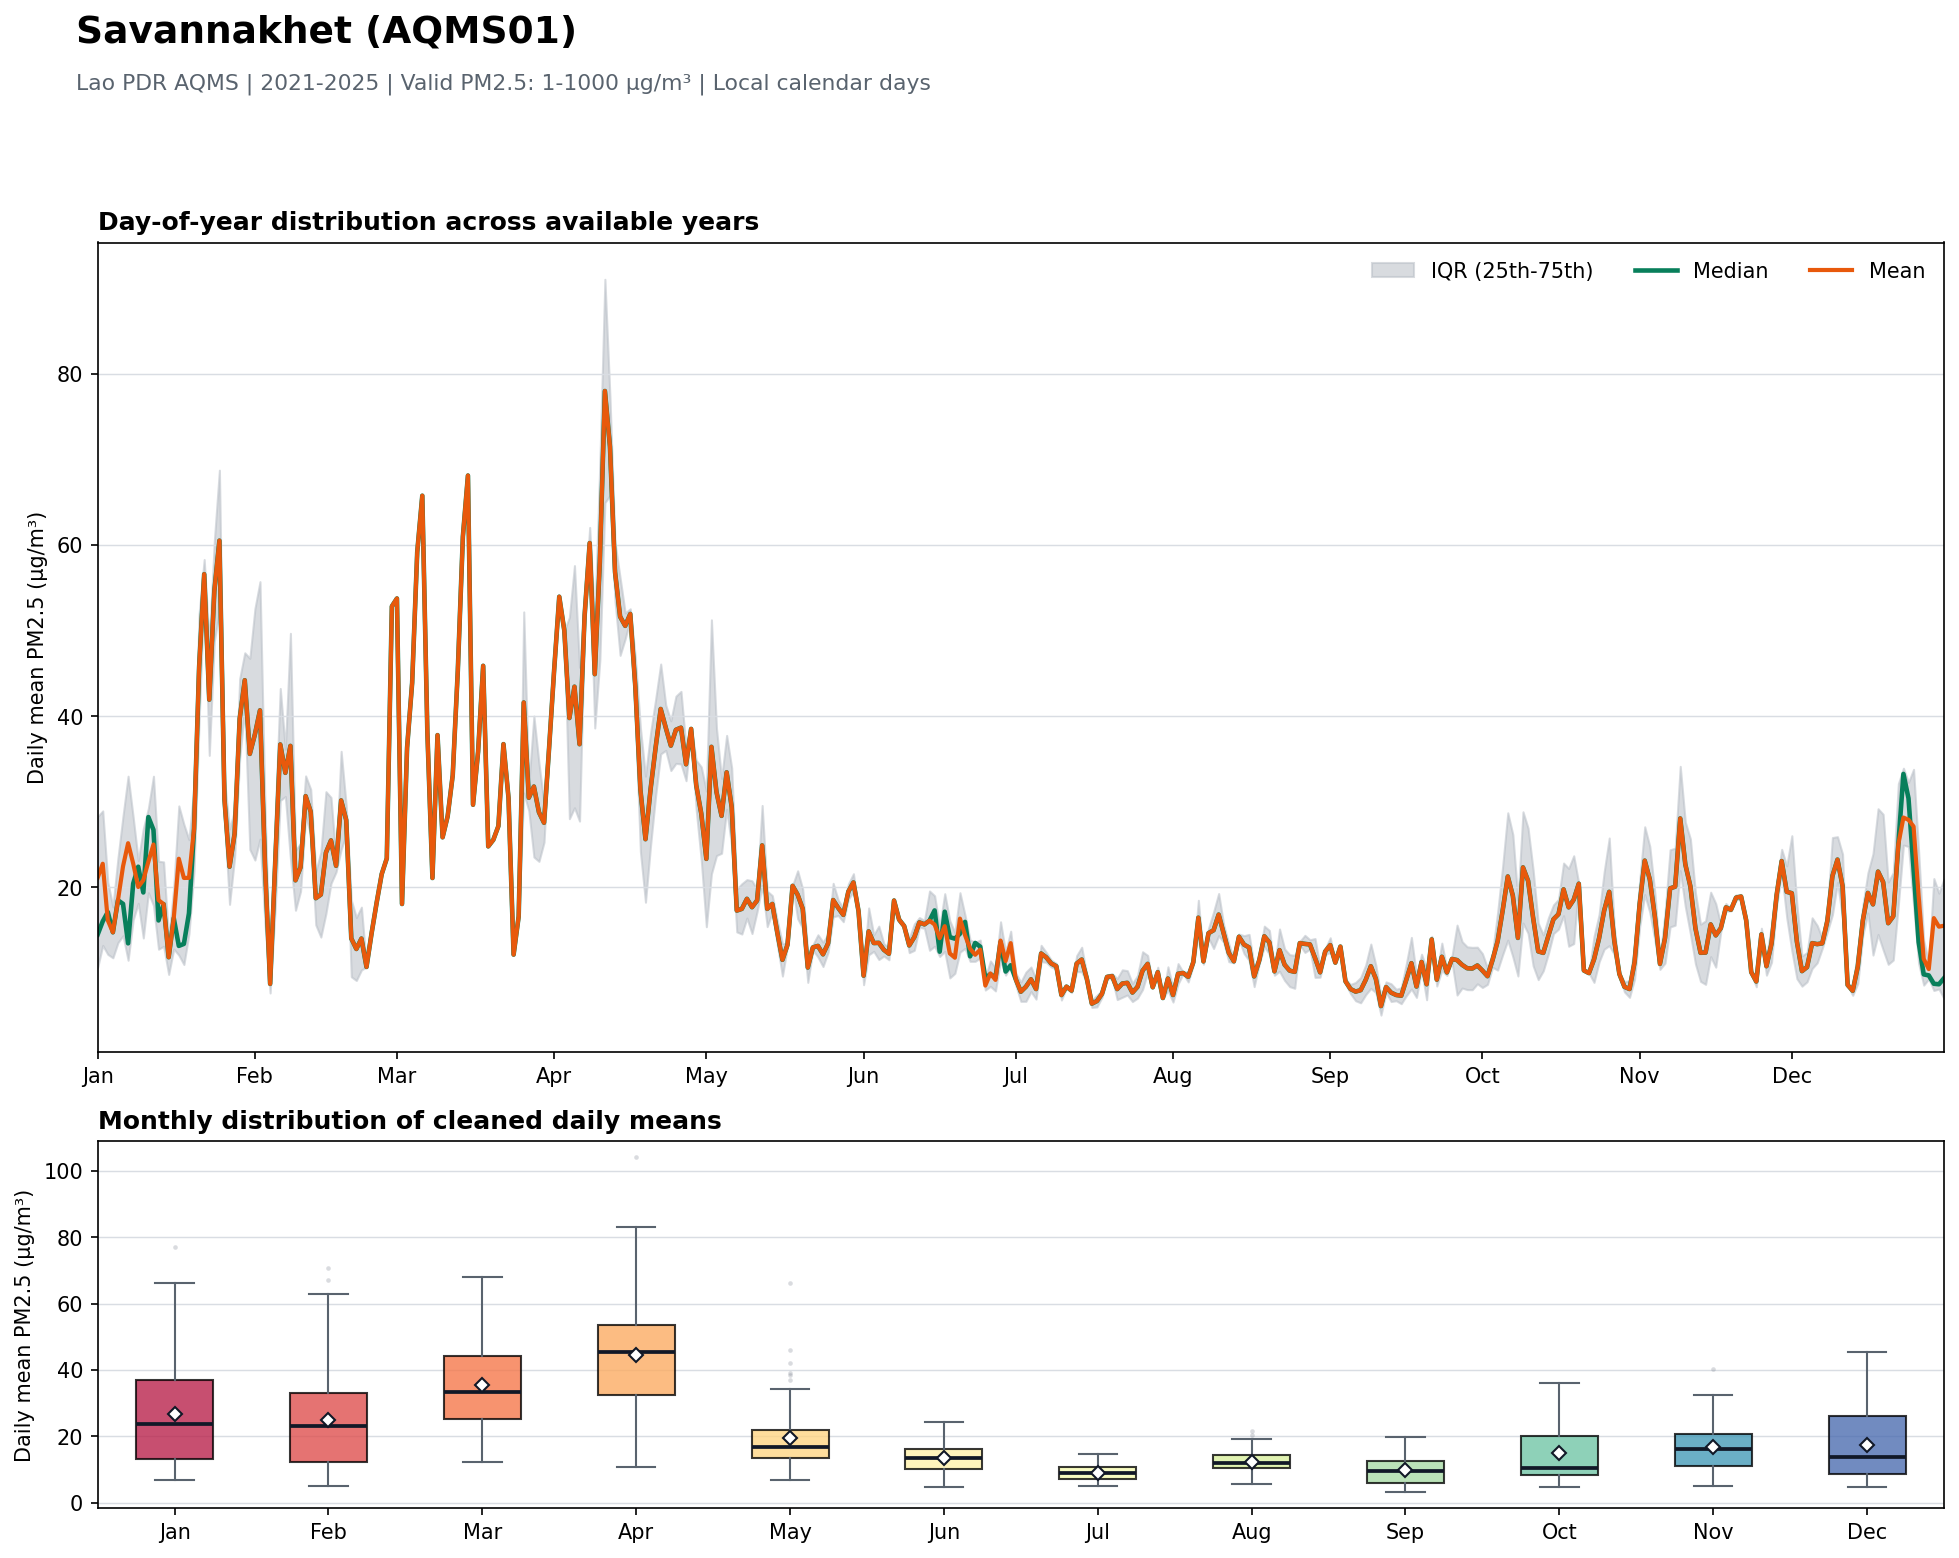

,month,daily_values,mean_pm25,median_pm25,q25_pm25,q75_pm25,month_name
0,1,76,26.800504,23.700000,13.209420,36.847917,Jan
1,2,50,24.827477,23.166667,12.205019,32.994158,Feb
2,3,36,35.453440,33.272917,25.337500,44.234375,Mar
3,4,57,44.363473,45.429167,32.304167,53.570833,Apr
4,5,62,19.362886,16.676087,13.534226,21.933063,May
5,6,76,13.334818,13.534783,10.062243,16.097917,Jun
6,7,62,9.083420,8.973913,6.980682,10.638291,Jul
7,8,62,12.196718,11.887228,10.331677,14.292708,Aug
8,9,60,9.857849,9.525362,6.004722,12.691193,Sep
9,10,59,14.850577,10.545455,8.184343,19.966667,Oct


Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_AQMS01_day_of_year_summary.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_AQMS01_monthly_summary.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_AQMS01_daily_climatology_and_monthly.png


In [6]:
# --- What this cell does ---
# Summarizes the selected station by day of year and by calendar month.
# Calculates medians, means, and interquartile ranges across years.
# Plots year-on-year behavior and month-wise station patterns.
# --- End annotation ---

day_of_year_summary = (
    daily_station.groupby("day_of_year", as_index=False)
    .agg(
        mean_pm25=("daily_mean_pm25", "mean"),
        median_pm25=("daily_mean_pm25", "median"),
        q25_pm25=("daily_mean_pm25", lambda values: values.quantile(0.25)),
        q75_pm25=("daily_mean_pm25", lambda values: values.quantile(0.75)),
        years_available=("year", "nunique"),
    )
    .set_index("day_of_year")
    .reindex(range(1, 366))
    .rename_axis("day_of_year")
    .reset_index()
)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_summary = (
    daily_station.groupby("month", as_index=False)
    .agg(
        daily_values=("daily_mean_pm25", "size"),
        mean_pm25=("daily_mean_pm25", "mean"),
        median_pm25=("daily_mean_pm25", "median"),
        q25_pm25=("daily_mean_pm25", lambda values: values.quantile(0.25)),
        q75_pm25=("daily_mean_pm25", lambda values: values.quantile(0.75)),
    )
    .set_index("month")
    .reindex(range(1, 13))
    .rename_axis("month")
    .reset_index()
)
monthly_summary["month_name"] = month_names

fig, (ax_doy, ax_month) = plt.subplots(
    2, 1, figsize=(14, 11), dpi=150, gridspec_kw={"height_ratios": [2.2, 1]}
)

x = day_of_year_summary["day_of_year"].to_numpy()
q25 = day_of_year_summary["q25_pm25"].to_numpy(dtype=float)
q75 = day_of_year_summary["q75_pm25"].to_numpy(dtype=float)
median = day_of_year_summary["median_pm25"].to_numpy(dtype=float)
mean = day_of_year_summary["mean_pm25"].to_numpy(dtype=float)

ax_doy.fill_between(x, q25, q75, color="#b8bec6", alpha=0.55, label="IQR (25th-75th)")
ax_doy.plot(x, median, color="#087f5b", linewidth=2.2, label="Median")
ax_doy.plot(x, mean, color="#e8590c", linewidth=2.0, label="Mean")

month_starts = pd.date_range("2001-01-01", "2001-12-01", freq="MS")
ax_doy.set_xticks(month_starts.dayofyear)
ax_doy.set_xticklabels(month_starts.strftime("%b"))
ax_doy.set_xlim(1, 365)
ax_doy.set_ylabel("Daily mean PM2.5 (µg/m³)")
ax_doy.set_title("Day-of-year distribution across available years", loc="left")
ax_doy.grid(axis="y", color="#d9dde3", linewidth=0.7)
ax_doy.legend(frameon=False, ncol=3, loc="upper right")

monthly_values = [
    daily_station.loc[daily_station["month"] == month, "daily_mean_pm25"].dropna().to_numpy()
    for month in range(1, 13)
]
box = ax_month.boxplot(
    monthly_values,
    patch_artist=True,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "#111827", "markersize": 5},
    medianprops={"color": "#111827", "linewidth": 1.8},
    whiskerprops={"color": "#59636e"},
    capprops={"color": "#59636e"},
    flierprops={"marker": "o", "markersize": 2.2, "markerfacecolor": "#6b7280", "markeredgecolor": "none", "alpha": 0.25},
)
ax_month.set_xticks(range(1, 13), month_names)
month_colors = plt.cm.Spectral(np.linspace(0.05, 0.95, 12))
for patch, color in zip(box["boxes"], month_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.78)

ax_month.set_ylabel("Daily mean PM2.5 (µg/m³)")
ax_month.set_title("Monthly distribution of cleaned daily means", loc="left")
ax_month.grid(axis="y", color="#d9dde3", linewidth=0.7)

start_year = int(daily_station["year"].min())
end_year = int(daily_station["year"].max())
station_title = f"{selected_station['station_name']} ({STATION_CODE})"
fig.suptitle(
    station_title,
    fontsize=18,
    fontweight="semibold",
    x=0.08,
    ha="left",
)
fig.text(
    0.08,
    0.935,
    f"{selected_network} | {start_year}-{end_year} | Valid PM2.5: 1-1000 µg/m³ | Local calendar days",
    fontsize=10.5,
    color="#59636e",
)
fig.tight_layout(rect=[0.04, 0.04, 0.98, 0.91])

climatology_output = OUTPUT_DIR / f"module2_{STATION_CODE}_day_of_year_summary.csv"
monthly_output = OUTPUT_DIR / f"module2_{STATION_CODE}_monthly_summary.csv"
figure_output = OUTPUT_DIR / f"module2_{STATION_CODE}_daily_climatology_and_monthly.png"
day_of_year_summary.to_csv(climatology_output, index=False)
monthly_summary.to_csv(monthly_output, index=False)
fig.savefig(figure_output, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

display(monthly_summary)
print("Saved:", climatology_output)
print("Saved:", monthly_output)
print("Saved:", figure_output)


### 1.5 Visualize station coverage and screened PM2.5

The station map answers *where* Thai PCD and Lao PDR AQMS provide observations. The distribution plot answers *what concentration regimes* appear after QA/QC. Dense spatial coverage does not guarantee equal temporal completeness, so both views are needed before collocation.


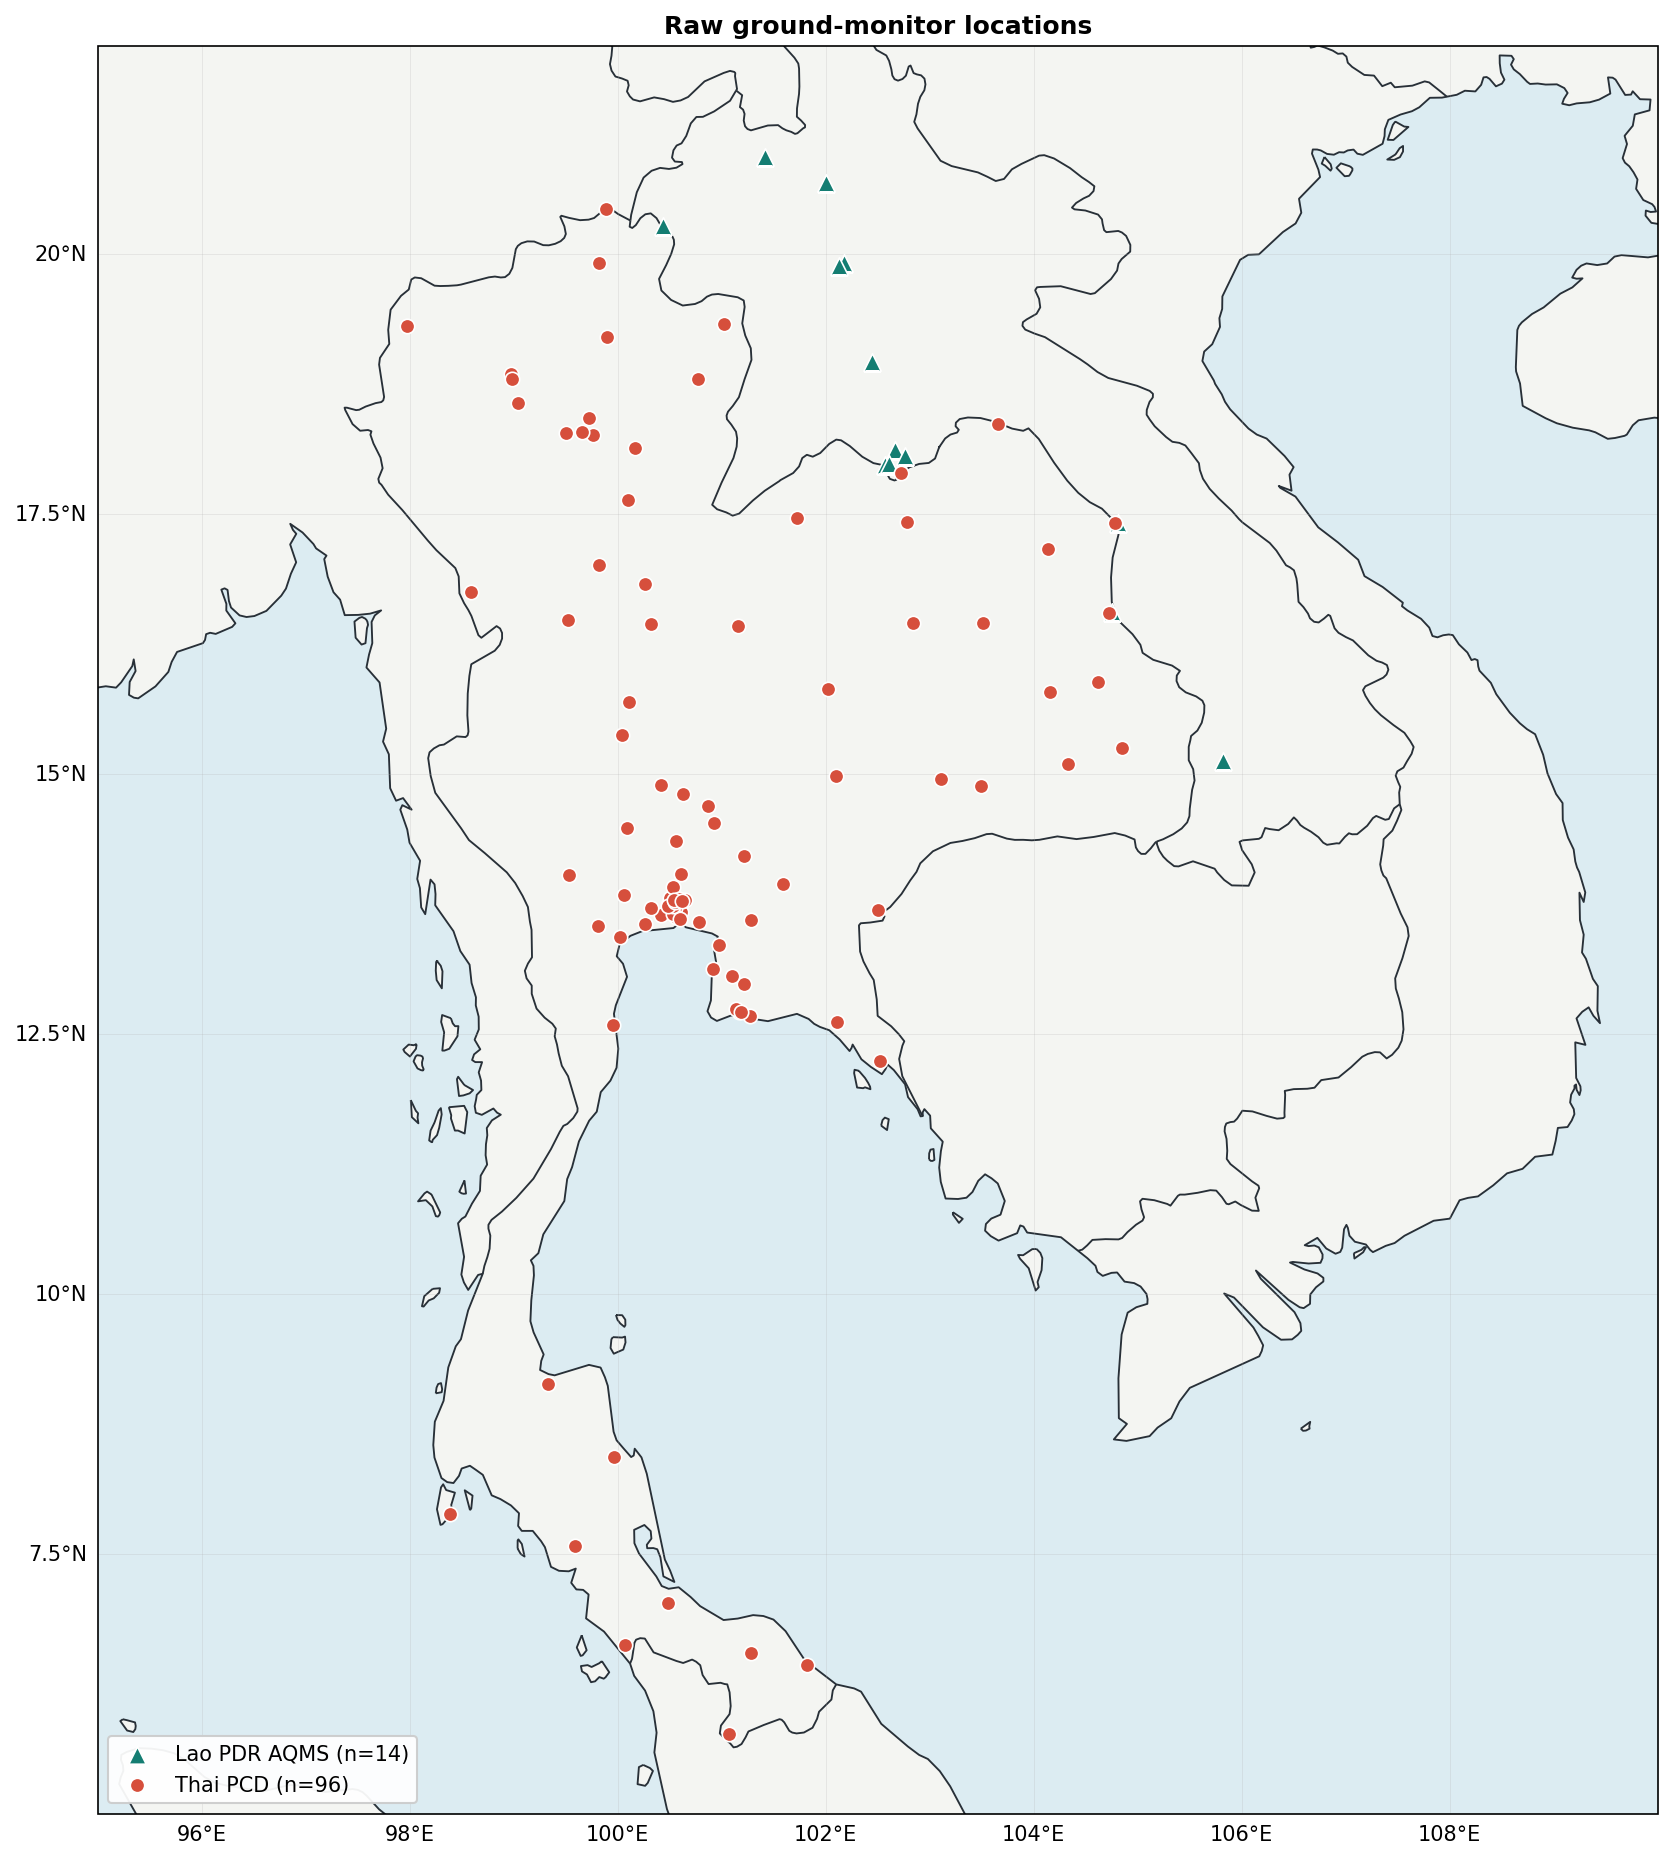

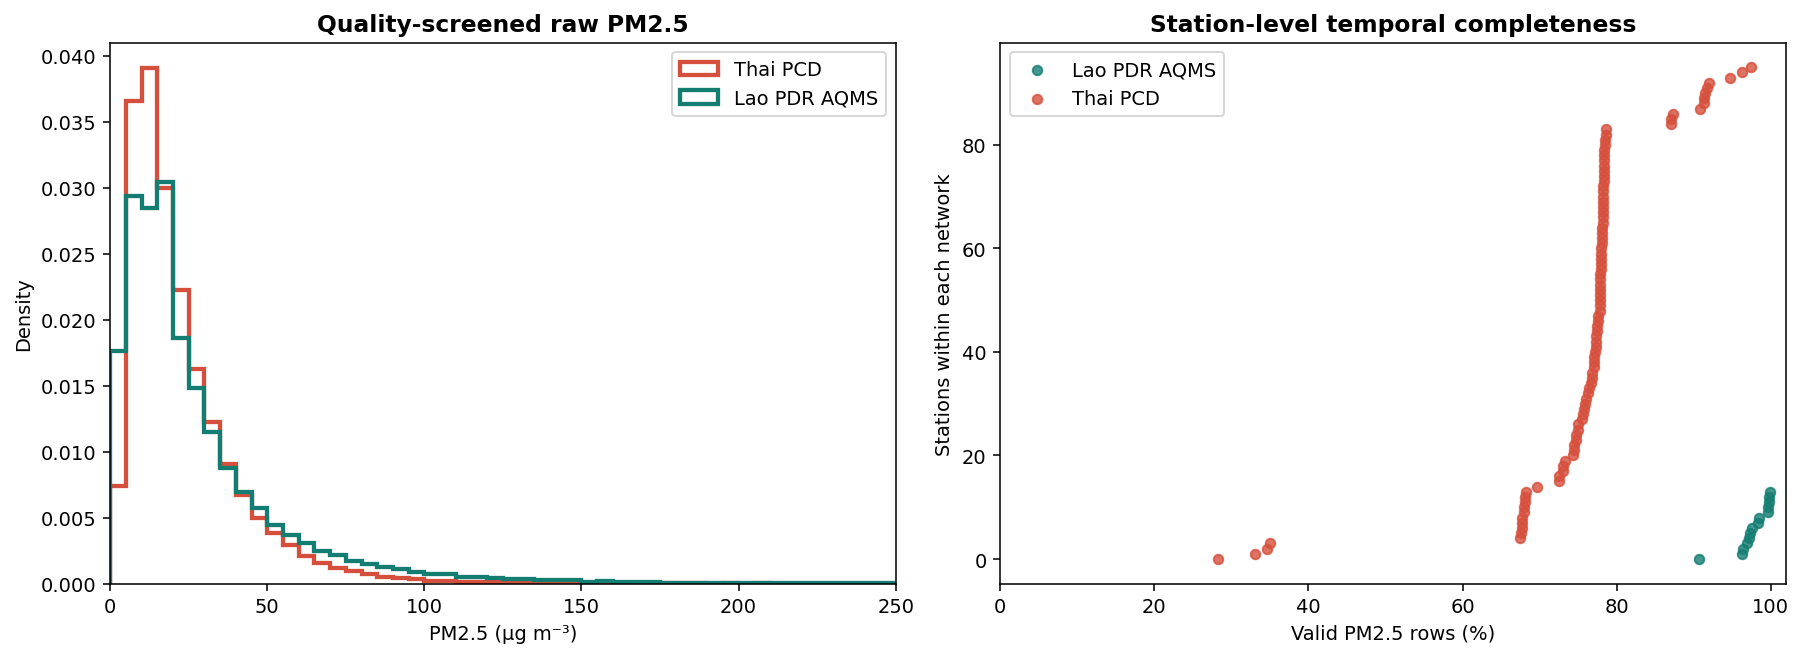

Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_raw_station_locations.png
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_raw_pm25_profile.png


In [7]:
# --- What this cell does ---
# Plots the station network after QA/QC using consistent colors for Thai PCD and Lao PDR AQMS.
# Uses station coordinates from the saved summary rather than inferring locations from filenames.
# --- End annotation ---

network_style = {
    "Thai PCD": {"color": "#d64f3c", "marker": "o"},
    "Lao PDR AQMS": {"color": "#147d72", "marker": "^"},
}

fig = plt.figure(figsize=(12, 12.5), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([95, 110, 5, 22], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f4f5f2", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dcecf2", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.9, edgecolor="#283038")
ax.add_feature(cfeature.BORDERS, linewidth=0.9, edgecolor="#283038")

for network, group in station_summary.groupby("network"):
    style = network_style[network]
    ax.scatter(
        group["lon"], group["lat"],
        s=70 if network == "Lao PDR AQMS" else 48,
        color=style["color"], marker=style["marker"],
        edgecolor="white", linewidth=0.8,
        transform=ccrs.PlateCarree(), label=f"{network} (n={len(group)})", zorder=4,
    )

gridlines = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.35)
gridlines.top_labels = False
gridlines.right_labels = False
ax.legend(loc="lower left", frameon=True, framealpha=0.94)
ax.set_title("Raw ground-monitor locations")
plt.tight_layout()
station_map_file = OUTPUT_DIR / "module2_raw_station_locations.png"
plt.savefig(station_map_file, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=140)
for network, color in (("Thai PCD", "#d64f3c"), ("Lao PDR AQMS", "#147d72")):
    values = np.concatenate(distribution_samples[network])
    axes[0].hist(values, bins=np.arange(0, 255, 5), density=True, histtype="step", linewidth=2.2, color=color, label=network)
axes[0].set_xlim(0, 250)
axes[0].set_xlabel("PM2.5 (µg m⁻³)")
axes[0].set_ylabel("Density")
axes[0].set_title("Quality-screened raw PM2.5")
axes[0].legend()

coverage = station_summary.sort_values("valid_fraction")
for network, group in coverage.groupby("network"):
    axes[1].scatter(
        group["valid_fraction"] * 100,
        np.arange(len(group)),
        s=24, alpha=0.8, color=network_style[network]["color"], label=network,
    )
axes[1].set_xlim(0, 102)
axes[1].set_xlabel("Valid PM2.5 rows (%)")
axes[1].set_ylabel("Stations within each network")
axes[1].set_title("Station-level temporal completeness")
axes[1].legend()
fig.tight_layout()
profile_file = OUTPUT_DIR / "module2_raw_pm25_profile.png"
fig.savefig(profile_file, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", station_map_file)
print("Saved:", profile_file)

## Section 2: GEOS grid collocation

### 2.1 Inspect the GEOS approximately 25 km grid

The grid template is derived from `GEOS_Data/20191123.nc`. Only the latitude and longitude coordinate arrays are required for spatial collocation. This regional grid has **0.25° latitude × 0.3125° longitude** spacing.

The physical east–west distance represented by a longitude interval decreases toward the poles. Therefore, “25 km” is an approximate product label rather than a constant square-cell dimension, and latitude/longitude differences should not be treated as ordinary Cartesian distances.


In [8]:
# --- What this cell does ---
# Opens one GEOS file and inspects latitude and longitude coordinates.
# The grid is opened once because all stations will be matched to this same grid geometry.
# --- End annotation ---

grid = xr.open_dataset(GRID_FILE)
geos_lats = grid["lat"].values
geos_lons = grid["lon"].values

print(grid)
print("Latitude spacing:", float(np.median(np.diff(geos_lats))), "degrees")
print("Longitude spacing:", float(np.median(np.diff(geos_lons))), "degrees")
print("Grid centers:", len(geos_lats) * len(geos_lons))

<xarray.Dataset> Size: 2kB
Dimensions:  (lat: 141, lon: 164)
Coordinates:
  * lat      (lat) float64 1kB 5.0 5.25 5.5 5.75 6.0 ... 39.25 39.5 39.75 40.0
  * lon      (lon) float64 1kB 59.06 59.38 59.69 60.0 ... 109.4 109.7 110.0
Data variables:
    *empty*
Attributes:
    title:               GEOS approximately 25 km grid template for station c...
    source_grid_file:    20191123.nc
    grid_description:    0.25 degree latitude by 0.3125 degree longitude regi...
    collocation_method:  nearest grid-cell center using Haversine distance
Latitude spacing: 0.25 degrees
Longitude spacing: 0.3125 degrees
Grid centers: 23124


### 2.2 Match each station to the nearest grid center

The collocation method uses one observation location and the center coordinates of every GEOS grid cell:

1. Read the station latitude and longitude.
2. Construct the two-dimensional GEOS latitude–longitude grid.
3. Convert all angular coordinates from degrees to radians.
4. Calculate the Haversine great-circle distance from the station to every grid center.
5. Select the grid center with the minimum distance.
6. Save its latitude index, longitude index, flattened grid index, center coordinates, and distance in kilometers.

For station coordinates $(\phi_1,\lambda_1)$ and grid-center coordinates $(\phi_2,\lambda_2)$:

\[
a = \sin^2\left(\frac{\Delta\phi}{2}\right)
  + \cos(\phi_1)\cos(\phi_2)
    \sin^2\left(\frac{\Delta\lambda}{2}\right)
\]

\[
d = 2R\,\operatorname{atan2}\left(\sqrt{a},\sqrt{1-a}\right)
\]

where $\phi$ is latitude, $\lambda$ is longitude, $\Delta\phi=\phi_2-\phi_1$, $\Delta\lambda=\lambda_2-\lambda_1$, and $R=6371.0088$ km is the mean Earth radius.

**Why Haversine?** It measures distance over a spherical Earth and accounts for longitude convergence with latitude. A Euclidean calculation performed directly on degrees would assign the same physical length to one degree of longitude everywhere, which is incorrect.

**Methodological scope:** this is nearest-center collocation. It does not perform bilinear interpolation, area averaging, elevation adjustment, or representativeness correction. Multiple stations can select the same GEOS cell and therefore receive the same model value at a given timestamp.


In [9]:
# --- What this cell does ---
# Implements the Haversine formula for spherical distance.
# Calculates distance from every station to every GEOS grid center.
# Stores the nearest grid latitude, longitude, row, column, and distance for each station.
# --- End annotation ---

EARTH_RADIUS_KM = 6371.0088
grid_lon_2d, grid_lat_2d = np.meshgrid(geos_lons, geos_lats)


def haversine_grid_km(station_lat, station_lon, grid_lat, grid_lon):
    station_lat_rad = np.radians(station_lat)
    station_lon_rad = np.radians(station_lon)
    grid_lat_rad = np.radians(grid_lat)
    grid_lon_rad = np.radians(grid_lon)
    delta_lat = grid_lat_rad - station_lat_rad
    delta_lon = grid_lon_rad - station_lon_rad
    # Haversine converts angular separation on a sphere into great-circle distance.
    a = (
        np.sin(delta_lat / 2.0) ** 2
        + np.cos(station_lat_rad) * np.cos(grid_lat_rad) * np.sin(delta_lon / 2.0) ** 2
    )
    return EARTH_RADIUS_KM * 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))


collocation_rows = []
for station in station_summary.itertuples(index=False):
    distances = haversine_grid_km(station.lat, station.lon, grid_lat_2d, grid_lon_2d)
    flat_index = int(np.nanargmin(distances))
    lat_index, lon_index = np.unravel_index(flat_index, distances.shape)
    collocation_rows.append({
        "network": station.network,
        "station_code": station.station_code,
        "station_name": station.station_name,
        "source_file": station.source_file,
        "station_lat": station.lat,
        "station_lon": station.lon,
        "geos_grid_index": flat_index,
        "geos_lat_index": int(lat_index),
        "geos_lon_index": int(lon_index),
        "geos_grid_lat": float(geos_lats[lat_index]),
        "geos_grid_lon": float(geos_lons[lon_index]),
        "geos_distance_km": float(distances[lat_index, lon_index]),
        "geos_lat_count": len(geos_lats),
        "geos_lon_count": len(geos_lons),
        "geos_grid_template": GRID_FILE.name,
    })

collocation = pd.DataFrame(collocation_rows).sort_values(["network", "station_code"]).reset_index(drop=True)
collocation_file = OUTPUT_DIR / "module2_pcd_aqms_geos25km_collocation.csv"
collocation.to_csv(collocation_file, index=False)

display(collocation.head(10))
display(collocation.groupby("network")["geos_distance_km"].agg(["count", "mean", "median", "max"]))
print("Saved:", collocation_file)

,network,station_code,station_name,source_file,station_lat,station_lon,geos_grid_index,geos_lat_index,geos_lon_index,geos_grid_lat,geos_grid_lon,geos_distance_km,geos_lat_count,geos_lon_count,geos_grid_template
0,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,16.554278,104.755639,7690,46,146,16.50,104.6875,9.443905,141,164,geos_25km_grid_template.nc
1,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.404750,104.808250,8346,50,146,17.50,104.6875,16.620459,141,164,geos_25km_grid_template.nc
2,Lao PDR AQMS,AQMS03,Houayxay,AQMS03.csv,20.261861,100.437139,10136,61,132,20.25,100.3125,13.068835,141,164,geos_25km_grid_template.nc
3,Lao PDR AQMS,AQMS04,Muang Xay,AQMS04.csv,20.673833,102.001583,10469,63,137,20.75,101.8750,15.654619,141,164,geos_25km_grid_template.nc
4,Lao PDR AQMS,AQMS05,Luang Namtha,AQMS05.csv,20.930750,101.415778,10632,64,136,21.00,101.5625,17.070148,141,164,geos_25km_grid_template.nc
5,Lao PDR AQMS,AQMS06,Vientiane,AQMS06.csv,17.962528,102.606056,8667,52,139,18.00,102.5000,11.965770,141,164,geos_25km_grid_template.nc
6,Lao PDR AQMS,AQMS07,Luang Prabang,AQMS07.csv,19.908944,102.178222,9978,60,138,20.00,102.1875,10.171261,141,164,geos_25km_grid_template.nc
7,Lao PDR AQMS,AQMS08,Vientiane,AQMS08.csv,17.970194,102.571000,8667,52,139,18.00,102.5000,8.207951,141,164,geos_25km_grid_template.nc
8,Lao PDR AQMS,AQMS09,Xaythany,AQMS09.csv,18.106194,102.663528,8668,52,140,18.00,102.8125,19.684561,141,164,geos_25km_grid_template.nc
9,Lao PDR AQMS,AQMS10,Xaythany,AQMS10.csv,18.053361,102.763333,8668,52,140,18.00,102.8125,7.888795,141,164,geos_25km_grid_template.nc


,count,mean,median,max
network,,,,
Lao PDR AQMS,14,12.965508,12.537358,19.684561
Thai PCD,96,11.567199,12.354620,20.805048


Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_pcd_aqms_geos25km_collocation.csv


### 2.3 Diagnose the station-to-grid matches

Lines connect each monitor to its selected grid center, while the histogram summarizes collocation distance. For stations located inside the grid domain, distances should generally remain below roughly half of the local grid-cell diagonal.

Investigate unusually large distances before extracting model data. Common causes include reversed latitude/longitude columns, a `0–360°` versus `−180–180°` longitude mismatch, incorrect station coordinates, or a station outside the model domain. Distance is a diagnostic, not a universal acceptance threshold.


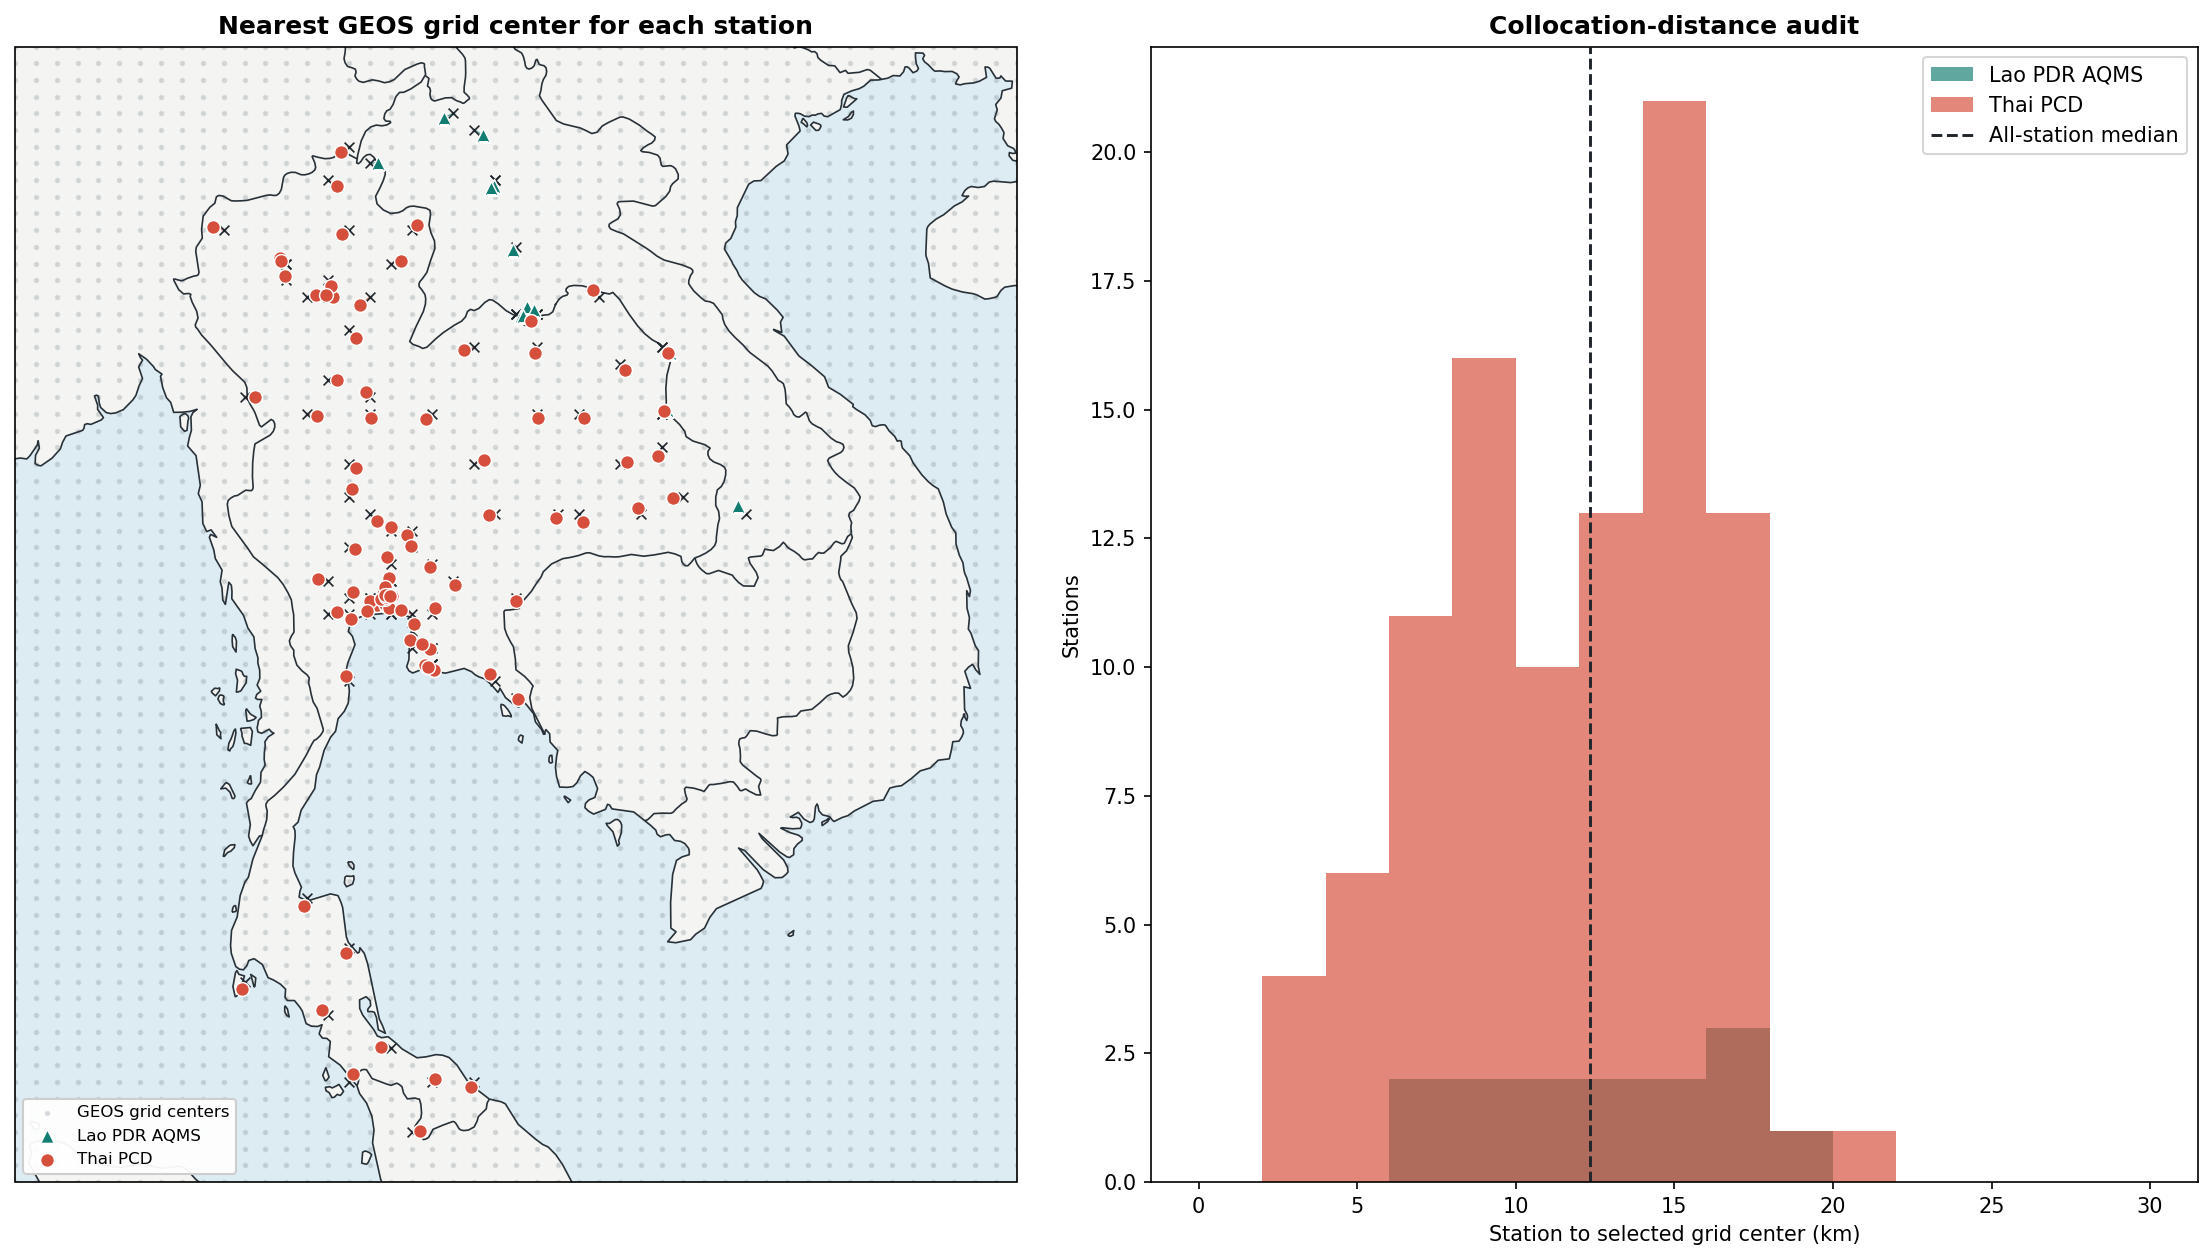

Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos25km_collocation_diagnostic.png


In [10]:
# --- What this cell does ---
# Maps station locations and their selected GEOS grid centers.
# Connects each station-grid pair so large collocation distances can be spotted visually.
# --- End annotation ---

fig = plt.figure(figsize=(15, 8.5), dpi=150)
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_hist = fig.add_subplot(1, 2, 2)

ax_map.set_extent([95, 110, 5, 22], crs=ccrs.PlateCarree())
ax_map.add_feature(cfeature.LAND, facecolor="#f4f5f2", zorder=0)
ax_map.add_feature(cfeature.OCEAN, facecolor="#dcecf2", zorder=0)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#283038")
ax_map.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="#283038")

visible_lon = geos_lons[(geos_lons >= 95) & (geos_lons <= 110)]
visible_lat = geos_lats[(geos_lats >= 5) & (geos_lats <= 22)]
visible_lon_2d, visible_lat_2d = np.meshgrid(visible_lon, visible_lat)
ax_map.scatter(
    visible_lon_2d.ravel(), visible_lat_2d.ravel(),
    s=3, color="#7d8790", alpha=0.20,
    transform=ccrs.PlateCarree(), zorder=1, label="GEOS grid centers",
)

for row in collocation.itertuples(index=False):
    color = network_style[row.network]["color"]
    ax_map.plot(
        [row.station_lon, row.geos_grid_lon],
        [row.station_lat, row.geos_grid_lat],
        color=color, linewidth=0.7, alpha=0.65,
        transform=ccrs.PlateCarree(), zorder=2,
    )
    ax_map.scatter(
        row.geos_grid_lon, row.geos_grid_lat,
        marker="x", s=22, linewidth=0.8, color="#20252b",
        transform=ccrs.PlateCarree(), zorder=3,
    )

for network, group in collocation.groupby("network"):
    style = network_style[network]
    ax_map.scatter(
        group["station_lon"], group["station_lat"],
        s=44, color=style["color"], marker=style["marker"],
        edgecolor="white", linewidth=0.7,
        transform=ccrs.PlateCarree(), zorder=4, label=network,
    )

ax_map.set_title("Nearest GEOS grid center for each station")
ax_map.legend(loc="lower left", fontsize=8, framealpha=0.95)

for network, group in collocation.groupby("network"):
    ax_hist.hist(
        group["geos_distance_km"], bins=np.arange(0, 31, 2),
        alpha=0.68, color=network_style[network]["color"], label=network,
    )
ax_hist.axvline(collocation["geos_distance_km"].median(), color="#20252b", linestyle="--", linewidth=1.4, label="All-station median")
ax_hist.set_xlabel("Station to selected grid center (km)")
ax_hist.set_ylabel("Stations")
ax_hist.set_title("Collocation-distance audit")
ax_hist.legend()

fig.tight_layout()
collocation_plot_file = OUTPUT_DIR / "module2_geos25km_collocation_diagnostic.png"
fig.savefig(collocation_plot_file, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", collocation_plot_file)

### 2.4 Validate and save the collocation lookup table

The final checks verify that every station has one selected grid cell, finite coordinates, valid row and column indices, and a reproducible flattened index. The output CSV becomes the spatial lookup table used by later modules to retrieve GEOS values at each monitoring location.

Retaining station coordinates, grid-center coordinates, indices, and Haversine distance makes every model–observation pairing traceable.


In [11]:
# --- What this cell does ---
# Runs structural checks on the collocation table before saving it.
# Verifies station counts, unique station keys, valid indices, and finite distances.
# --- End annotation ---

expected_station_count = len(pcd_files) + len(aqms_files)

assert len(collocation) == expected_station_count
assert collocation["station_code"].notna().all()
assert collocation["geos_lat_index"].between(0, len(geos_lats) - 1).all()
assert collocation["geos_lon_index"].between(0, len(geos_lons) - 1).all()
assert (
    collocation["geos_grid_index"]
    == collocation["geos_lat_index"] * len(geos_lons) + collocation["geos_lon_index"]
).all()
assert collocation["geos_distance_km"].max() < 30

print("Sanity checks passed.")
print("Stations collocated:", len(collocation))
print("Unique selected GEOS cells:", collocation["geos_grid_index"].nunique())
print("Maximum collocation distance: %.2f km" % collocation["geos_distance_km"].max())
print("\nNext module: extract GEOS variables at these fixed grid indices and align 3-hour UTC model times with ground observations.")

Sanity checks passed.
Stations collocated: 110
Unique selected GEOS cells: 81
Maximum collocation distance: 20.81 km

Next module: extract GEOS variables at these fixed grid indices and align 3-hour UTC model times with ground observations.


## Section 3: Extract GEOS values at the collocated grid points

This worked example reads two consecutive GEOS NetCDF files and extracts **every data variable that contains both `lat` and `lon` dimensions** at all collocated Thai PCD and Lao PDR AQMS grid points. Variables may also contain `time`; all available timestamps are retained.

The two files have overlapping valid times. Therefore, `valid_time_utc` alone is not a unique forecast identifier. Every extracted row also retains its source NetCDF filename and the forecast reference date parsed from that filename.

### 3.1 Traceability design

| Trace level | Fields retained |
| --- | --- |
| Source file | full path, filename, file size, dimensions, reference date, first and last valid time |
| Variable | name, role, dimensions, dtype, units, long name, extraction status |
| Station | network, station code, station name/area, observation coordinates and source CSV |
| Collocation | latitude index, longitude index, flattened index, selected grid coordinates, Haversine distance |
| Forecast time | valid time, reference date, lead hours, forecast day |
| Extracted value | variable name, original value, numeric representation when applicable, units and dtype |

The extraction creates four CSV files:

1. a **wide table** with one row per source file, station, and valid time;
2. a **long value trace** with one row per extracted variable value;
3. a **source-file trace** describing the two NetCDF inputs; and
4. a **variable trace** documenting extracted and metadata-only variables.


In [12]:
# --- What this cell does ---
# Selects two GEOS files and inventories dimensions, coordinates, and variables.
# Creates source and variable provenance tables before extracting any values.
# --- End annotation ---

GEOS_FILES = [
    GEOS_DATA_DIR / "20230505.nc",
    GEOS_DATA_DIR / "20230506.nc",
]

missing_geos_files = [source_file for source_file in GEOS_FILES if not source_file.exists()]
if missing_geos_files:
    raise FileNotFoundError(
        "The two GEOS exercise files were not found: "
        + ", ".join(str(source_file) for source_file in missing_geos_files)
    )

source_trace_rows = []
variable_trace_rows = []

for source_file in GEOS_FILES:
    with xr.open_dataset(source_file, decode_times=True) as dataset:
        reference_date = pd.to_datetime(source_file.stem, format="%Y%m%d", errors="coerce", utc=True)
        valid_times = pd.to_datetime(dataset["time"].values, errors="coerce", utc=True)
        extractable_variables = [
            variable_name
            for variable_name, variable in dataset.data_vars.items()
            if "lat" in variable.dims and "lon" in variable.dims
        ]
        grid_matches_template = (
            dataset.sizes.get("lat") == len(geos_lats)
            and dataset.sizes.get("lon") == len(geos_lons)
            and np.allclose(dataset["lat"].values, geos_lats)
            and np.allclose(dataset["lon"].values, geos_lons)
        )

        source_trace_rows.append({
            "source_geos_file": source_file.name,
            "source_geos_path": str(source_file),
            "file_size_bytes": source_file.stat().st_size,
            "forecast_reference_date_utc": reference_date,
            "lat_count": dataset.sizes.get("lat"),
            "lon_count": dataset.sizes.get("lon"),
            "time_count": dataset.sizes.get("time", 1),
            "first_valid_time_utc": valid_times.min(),
            "last_valid_time_utc": valid_times.max(),
            "data_variable_count": len(dataset.data_vars),
            "extractable_variable_count": len(extractable_variables),
            "grid_matches_collocation_template": grid_matches_template,
        })

        for variable_name, variable in dataset.variables.items():
            is_data_variable = variable_name in dataset.data_vars
            has_spatial_grid = "lat" in variable.dims and "lon" in variable.dims
            if is_data_variable and has_spatial_grid:
                extraction_status = "extracted"
            elif not is_data_variable:
                extraction_status = "coordinate metadata"
            else:
                extraction_status = "not spatial: no lat/lon pair"
            variable_trace_rows.append({
                "source_geos_file": source_file.name,
                "variable": variable_name,
                "role": "data variable" if is_data_variable else "coordinate",
                "dimensions": ",".join(variable.dims),
                "dtype": str(variable.dtype),
                "units": variable.attrs.get("units", ""),
                "long_name": variable.attrs.get("long_name", ""),
                "extraction_status": extraction_status,
            })

source_trace = pd.DataFrame(source_trace_rows)
variable_trace = pd.DataFrame(variable_trace_rows)

display(source_trace)
display(variable_trace.loc[variable_trace["extraction_status"] == "extracted"].head(40))
print("Selected files:", [source_file.name for source_file in GEOS_FILES])
print("Extracted variables per file:", source_trace["extractable_variable_count"].tolist())


,source_geos_file,source_geos_path,file_size_bytes,forecast_reference_date_utc,lat_count,lon_count,time_count,first_valid_time_utc,last_valid_time_utc,data_variable_count,extractable_variable_count,grid_matches_collocation_template
0,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,106599117,2023-05-05 00:00:00+00:00,141,164,24,2023-05-05 01:30:00+00:00,2023-05-07 22:30:00+00:00,33,33,True
1,20230506.nc,{TRAINING_ROOT}/data/module2/geos/20230506.nc,106599117,2023-05-06 00:00:00+00:00,141,164,24,2023-05-06 01:30:00+00:00,2023-05-08 22:30:00+00:00,33,33,True


,source_geos_file,variable,role,dimensions,dtype,units,long_name,extraction_status
0,20230505.nc,lonArray,data variable,"lat,lon,time",float64,,,extracted
1,20230505.nc,latArray,data variable,"lat,lon,time",float64,,,extracted
2,20230505.nc,timeArray,data variable,"lat,lon,time",datetime64[ns],,,extracted
3,20230505.nc,WIND,data variable,"lat,lon,time",float32,m/s,WIND,extracted
4,20230505.nc,PS,data variable,"lat,lon,time",float32,,,extracted
5,20230505.nc,Q500,data variable,"lat,lon,time",float32,,,extracted
6,20230505.nc,Q850,data variable,"lat,lon,time",float32,,,extracted
7,20230505.nc,QV10M,data variable,"lat,lon,time",float32,,,extracted
8,20230505.nc,T10M,data variable,"lat,lon,time",float32,kelvin,T10M,extracted
9,20230505.nc,T500,data variable,"lat,lon,time",float32,,,extracted


Selected files: ['20230505.nc', '20230506.nc']
Extracted variables per file: [33, 33]


### 3.2 Extract by saved row and column indices

The extraction does **not** repeat the spatial search. It reuses `geos_lat_index` and `geos_lon_index` from the collocation lookup table. This is important for reproducibility: the station-to-grid decision is made once, documented with its Haversine distance, and then applied identically to every NetCDF file.

For each source file, the code:

1. verifies that its latitude and longitude arrays match the grid used for collocation;
2. creates vectorized station index arrays;
3. applies both indices simultaneously with `xarray.isel`;
4. converts the selected station–time values to a table;
5. attaches station and collocation metadata;
6. calculates lead hours and forecast day from the filename date; and
7. reshapes a second copy to long form for value-level traceback.


In [13]:
# --- What this cell does ---
# Uses the saved grid row and column to extract every spatial GEOS variable at every station.
# Preserves initialization time, valid time, lead hour, forecast day, grid indices, and source file.
# Writes wide analysis data plus long-form value lineage for detailed traceback.
# --- End annotation ---

station_metadata = (
    collocation.reset_index(names="station")
    .rename(columns={"source_file": "observation_source_file"})
)
station_lat_indices = xr.DataArray(
    station_metadata["geos_lat_index"].to_numpy(dtype=int),
    dims="station",
    coords={"station": station_metadata["station"].to_numpy()},
)
station_lon_indices = xr.DataArray(
    station_metadata["geos_lon_index"].to_numpy(dtype=int),
    dims="station",
    coords={"station": station_metadata["station"].to_numpy()},
)

wide_frames = []
lineage_example_frames = []
long_row_count = 0
long_variable_names = set()
long_output = OUTPUT_DIR / "module2_geos_two_file_collocated_long_trace.csv"
long_file_started = False

for source_file in GEOS_FILES:
    with xr.open_dataset(source_file, decode_times=True) as dataset:
        if not (
            dataset.sizes.get("lat") == len(geos_lats)
            and dataset.sizes.get("lon") == len(geos_lons)
            and np.allclose(dataset["lat"].values, geos_lats)
            and np.allclose(dataset["lon"].values, geos_lons)
        ):
            raise ValueError(f"Grid mismatch: {source_file}")

        extractable_variables = [
            variable_name
            for variable_name, variable in dataset.data_vars.items()
            if "lat" in variable.dims and "lon" in variable.dims
        ]
        selected = dataset[extractable_variables].isel(
            lat=station_lat_indices,
            lon=station_lon_indices,
        )
        frame = selected.to_dataframe().reset_index()
        frame = frame.rename(columns={
            "time": "valid_time_utc",
            "lat": "extracted_grid_lat",
            "lon": "extracted_grid_lon",
        })
        frame = frame.merge(station_metadata, on="station", how="left", validate="many_to_one")

        reference_date = pd.to_datetime(source_file.stem, format="%Y%m%d", errors="raise", utc=True)
        frame["valid_time_utc"] = pd.to_datetime(frame["valid_time_utc"], errors="coerce", utc=True)
        frame["source_geos_file"] = source_file.name
        frame["source_geos_path"] = str(source_file)
        frame["forecast_reference_date_utc"] = reference_date
        frame["lead_hours_from_reference_date"] = (
            frame["valid_time_utc"] - reference_date
        ).dt.total_seconds() / 3600.0
        frame["forecast_day"] = (
            (frame["valid_time_utc"].dt.normalize() - reference_date).dt.days + 1
        )

        if not np.allclose(frame["extracted_grid_lat"], frame["geos_grid_lat"]):
            raise AssertionError(f"Latitude index traceback failed for {source_file.name}")
        if not np.allclose(frame["extracted_grid_lon"], frame["geos_grid_lon"]):
            raise AssertionError(f"Longitude index traceback failed for {source_file.name}")

        trace_columns = [
            "source_geos_file",
            "source_geos_path",
            "forecast_reference_date_utc",
            "valid_time_utc",
            "lead_hours_from_reference_date",
            "forecast_day",
            "network",
            "station_code",
            "station_name",
            "observation_source_file",
            "station_lat",
            "station_lon",
            "geos_grid_index",
            "geos_lat_index",
            "geos_lon_index",
            "geos_grid_lat",
            "geos_grid_lon",
            "extracted_grid_lat",
            "extracted_grid_lon",
            "geos_distance_km",
        ]
        variable_metadata = variable_trace.loc[
            (variable_trace["source_geos_file"] == source_file.name)
            & (variable_trace["extraction_status"] == "extracted"),
            ["source_geos_file", "variable", "dimensions", "dtype", "units", "long_name"],
        ]
        long_frame = frame.melt(
            id_vars=trace_columns,
            value_vars=extractable_variables,
            var_name="variable",
            value_name="value",
        ).merge(
            variable_metadata,
            on=["source_geos_file", "variable"],
            how="left",
            validate="many_to_one",
        )
        long_frame["value_text"] = long_frame["value"].astype(str)
        long_frame["value_numeric"] = pd.to_numeric(long_frame["value"], errors="coerce")

        long_frame.to_csv(
            long_output,
            mode="a" if long_file_started else "w",
            header=not long_file_started,
            index=False,
        )
        long_file_started = True
        long_row_count += len(long_frame)
        long_variable_names.update(long_frame["variable"].unique())
        lineage_example_frames.append(
            long_frame.sort_values("valid_time_utc")
            .groupby(["station_code", "variable"], as_index=False)
            .head(1)
        )
        wide_frames.append(frame)
        del long_frame

geos_collocated_wide = pd.concat(wide_frames, ignore_index=True, sort=False)
geos_value_lineage_examples = pd.concat(lineage_example_frames, ignore_index=True, sort=False)

wide_output = OUTPUT_DIR / "module2_geos_two_file_collocated_wide.csv"
source_trace_output = OUTPUT_DIR / "module2_geos_two_file_source_trace.csv"
variable_trace_output = OUTPUT_DIR / "module2_geos_two_file_variable_trace.csv"

geos_collocated_wide.to_csv(wide_output, index=False)
source_trace.to_csv(source_trace_output, index=False)
variable_trace.to_csv(variable_trace_output, index=False)

expected_wide_rows = int(
    (source_trace["time_count"] * len(collocation)).sum()
)
expected_long_rows = int(
    (source_trace["time_count"] * source_trace["extractable_variable_count"] * len(collocation)).sum()
)
assert len(geos_collocated_wide) == expected_wide_rows
assert long_row_count == expected_long_rows
assert not geos_collocated_wide.duplicated(
    ["source_geos_file", "station_code", "valid_time_utc"]
).any()
assert source_trace["grid_matches_collocation_template"].all()

overlapping_valid_times = (
    geos_collocated_wide[["source_geos_file", "valid_time_utc"]]
    .drop_duplicates()
    .groupby("valid_time_utc")["source_geos_file"]
    .nunique()
    .gt(1)
    .sum()
)

print("Wide rows:", f"{len(geos_collocated_wide):,}")
print("Long trace rows:", f"{long_row_count:,}")
print("Stations:", geos_collocated_wide["station_code"].nunique())
print("Extracted variables:", len(long_variable_names))
print("Valid timestamps appearing in both source files:", int(overlapping_valid_times))
print("Saved:", wide_output)
print("Saved:", long_output)
print("Saved:", source_trace_output)
print("Saved:", variable_trace_output)

display(geos_collocated_wide.head())
display(geos_value_lineage_examples.head(12))


Wide rows: 5,280
Long trace rows: 174,240
Stations: 110
Extracted variables: 33
Valid timestamps appearing in both source files: 16
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_two_file_collocated_wide.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_two_file_collocated_long_trace.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_two_file_source_trace.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_two_file_variable_trace.csv


,station,valid_time_utc,lonArray,latArray,timeArray,WIND,PS,Q500,Q850,QV10M,...,geos_grid_lon,geos_distance_km,geos_lat_count,geos_lon_count,geos_grid_template,source_geos_file,source_geos_path,forecast_reference_date_utc,lead_hours_from_reference_date,forecast_day
0,0,2023-05-05 01:30:00+00:00,104.6875,16.5,2023-05-05 01:30:00,4.971058,98525.015625,0.001592,0.013581,0.015993,...,104.6875,9.443905,141,164,geos_25km_grid_template.nc,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,1.5,1
1,0,2023-05-05 04:30:00+00:00,104.6875,16.5,2023-05-05 04:30:00,4.101807,98341.890625,0.001602,0.014045,0.015192,...,104.6875,9.443905,141,164,geos_25km_grid_template.nc,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,4.5,1
2,0,2023-05-05 07:30:00+00:00,104.6875,16.5,2023-05-05 07:30:00,4.219115,97938.265625,0.001971,0.013415,0.014662,...,104.6875,9.443905,141,164,geos_25km_grid_template.nc,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,7.5,1
3,0,2023-05-05 10:30:00+00:00,104.6875,16.5,2023-05-05 10:30:00,3.907490,97836.890625,0.002289,0.013068,0.014957,...,104.6875,9.443905,141,164,geos_25km_grid_template.nc,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,10.5,1
4,0,2023-05-05 13:30:00+00:00,104.6875,16.5,2023-05-05 13:30:00,3.164265,98066.187500,0.002379,0.013188,0.014534,...,104.6875,9.443905,141,164,geos_25km_grid_template.nc,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,13.5,1


,source_geos_file,source_geos_path,forecast_reference_date_utc,valid_time_utc,lead_hours_from_reference_date,forecast_day,network,station_code,station_name,observation_source_file,...,extracted_grid_lon,geos_distance_km,variable,value,dimensions,dtype,units,long_name,value_text,value_numeric
0,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 01:30:00+00:00,1.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
1,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 04:30:00+00:00,4.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
2,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 07:30:00+00:00,7.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
3,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 10:30:00+00:00,10.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
4,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 13:30:00+00:00,13.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
5,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 16:30:00+00:00,16.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
6,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 19:30:00+00:00,19.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
7,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 22:30:00+00:00,22.5,1,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
8,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-06 01:30:00+00:00,25.5,2,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875
9,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-06 04:30:00+00:00,28.5,2,Lao PDR AQMS,AQMS01,Savannakhet,AQMS01.csv,...,104.6875,9.443905,lonArray,104.6875,"lat,lon,time",float64,,,104.6875,104.6875


### 3.3 Follow one extracted value from source to output

The worked trace below selects one `GEOSPM25` value for `AQMS01`. Reading the fields from top to bottom reconstructs the complete extraction decision:

**NetCDF source → forecast reference date → valid time → station → saved row/column indices → selected grid center → Haversine distance → variable metadata → extracted value.**

Change `TRACE_STATION_CODE` or `TRACE_VARIABLE` to audit another station or parameter.


In [14]:
# --- What this cell does ---
# Selects one station, one valid time, and one variable as a provenance example.
# Traces the output value back to its NetCDF file, variable, time index, latitude index, and longitude index.
# --- End annotation ---

TRACE_STATION_CODE = "AQMS01"
TRACE_VARIABLE = "GEOSPM25"

trace_example = (
    geos_value_lineage_examples.loc[
        (geos_value_lineage_examples["station_code"] == TRACE_STATION_CODE)
        & (geos_value_lineage_examples["variable"] == TRACE_VARIABLE)
    ]
    .sort_values(["forecast_reference_date_utc", "valid_time_utc"])
    .iloc[0]
)

traceback_fields = [
    "source_geos_path",
    "source_geos_file",
    "forecast_reference_date_utc",
    "valid_time_utc",
    "lead_hours_from_reference_date",
    "forecast_day",
    "network",
    "station_code",
    "station_name",
    "observation_source_file",
    "station_lat",
    "station_lon",
    "geos_lat_index",
    "geos_lon_index",
    "geos_grid_index",
    "geos_grid_lat",
    "geos_grid_lon",
    "geos_distance_km",
    "variable",
    "dimensions",
    "dtype",
    "units",
    "long_name",
    "value",
]

traceback_table = (
    trace_example[traceback_fields]
    .rename_axis("trace_field")
    .reset_index(name="trace_value")
)
display(traceback_table)

print(
    f"{TRACE_VARIABLE}={trace_example['value']} {trace_example['units']} was read from "
    f"{trace_example['source_geos_file']} at {trace_example['valid_time_utc']}, using "
    f"grid row {int(trace_example['geos_lat_index'])}, column {int(trace_example['geos_lon_index'])} "
    f"for {trace_example['station_name']} ({TRACE_STATION_CODE})."
)


,trace_field,trace_value
0,source_geos_path,{TRAINING_ROOT}/data/module2/geos/20230505.nc
1,source_geos_file,20230505.nc
2,forecast_reference_date_utc,2023-05-05 00:00:00+00:00
3,valid_time_utc,2023-05-05 01:30:00+00:00
4,lead_hours_from_reference_date,1.5
5,forecast_day,1
6,network,Lao PDR AQMS
7,station_code,AQMS01
8,station_name,Savannakhet
9,observation_source_file,AQMS01.csv


GEOSPM25=37.15373229980469 μg/m³ was read from 20230505.nc at 2023-05-05 01:30:00+00:00, using grid row 46, column 146 for Savannakhet (AQMS01).


## Section 4: Align ground observations with GEOS three-hour averages

GEOS values in these files represent three-hour averages timestamped at the midpoint of each UTC averaging interval. Ground observations must use the same time basis before comparison.

### 4.1 Convert local observations to UTC and form three-hour means

The Thai PCD and Lao PDR AQMS timestamps are first interpreted in local time (UTC+7) and converted to UTC. Valid hourly PM2.5 observations are then assigned to left-closed, right-open UTC intervals:

| UTC averaging interval | Comparison timestamp |
| --- | --- |
| `00:00 ≤ time < 03:00` | `01:30 UTC` |
| `03:00 ≤ time < 06:00` | `04:30 UTC` |
| `06:00 ≤ time < 09:00` | `07:30 UTC` |
| `09:00 ≤ time < 12:00` | `10:30 UTC` |
| `12:00 ≤ time < 15:00` | `13:30 UTC` |
| `15:00 ≤ time < 18:00` | `16:30 UTC` |
| `18:00 ≤ time < 21:00` | `19:30 UTC` |
| `21:00 ≤ time < 24:00` | `22:30 UTC` |

Only intervals containing exactly **three distinct valid hourly observations** are retained (`n_obs = 3`). The hourly validity range remains `1–1000 µg/m³`. For this worked example, ground processing is limited to the valid-time window covered by the two selected GEOS files.


In [15]:
# --- What this cell does ---
# Reads screened hourly observations only within the GEOS valid-time window.
# Collapses duplicate hours, forms fixed UTC three-hour bins, and places means at bin midpoints.
# Retains only bins containing exactly three distinct hourly observations.
# --- End annotation ---

ground_3h_frames = []
geos_valid_start = geos_collocated_wide["valid_time_utc"].min()
geos_valid_end = geos_collocated_wide["valid_time_utc"].max()
ground_window_start = geos_valid_start - pd.Timedelta(minutes=90)
ground_window_end = geos_valid_end + pd.Timedelta(minutes=90)

for station in station_summary.itertuples(index=False):
    observation_file = (
        PCD_DIR / station.source_file
        if station.network == "Thai PCD"
        else AQMS_DIR / station.source_file
    )
    station_data = (
        prepare_pcd(observation_file)
        if station.network == "Thai PCD"
        else prepare_aqms(observation_file)
    )
    valid_hourly = station_data.loc[
        station_data["pm25_is_valid"]
        & station_data["datetime_utc"].notna()
        & station_data["datetime_utc"].ge(ground_window_start)
        & station_data["datetime_utc"].lt(ground_window_end),
        ["datetime_local", "datetime_utc", "pm25_numeric"],
    ].copy()
    if valid_hourly.empty:
        continue

    # Collapse duplicate timestamps before counting the three distinct hourly observations.
    hourly_unique = (
        valid_hourly.groupby("datetime_utc", as_index=False)
        .agg(
            pm25_hourly=("pm25_numeric", "mean"),
            duplicate_rows_collapsed=("pm25_numeric", "size"),
        )
    )
    # floor('3h') assigns 00:00-02:59 to 00:00, 03:00-05:59 to 03:00, and so on.
    hourly_unique["bin_start_utc"] = hourly_unique["datetime_utc"].dt.floor("3h")

    station_3h = (
        hourly_unique.groupby("bin_start_utc", as_index=False)
        .agg(
            ground_pm25_3h=("pm25_hourly", "mean"),
            n_obs=("datetime_utc", "nunique"),
            first_hour_utc=("datetime_utc", "min"),
            last_hour_utc=("datetime_utc", "max"),
            source_rows=("duplicate_rows_collapsed", "sum"),
        )
    )
    station_3h["valid_time_utc"] = station_3h["bin_start_utc"] + pd.Timedelta(minutes=90)
    # Requiring three distinct hours prevents incomplete bins from being treated as full averages.
    station_3h = station_3h.loc[station_3h["n_obs"] == 3].copy()
    station_3h["network"] = station.network
    station_3h["station_code"] = station.station_code
    station_3h["station_name"] = station.station_name
    station_3h["observation_source_file"] = station.source_file
    station_3h["station_lat"] = station.lat
    station_3h["station_lon"] = station.lon
    ground_3h_frames.append(station_3h)

ground_observations_3h = pd.concat(ground_3h_frames, ignore_index=True)
ground_observations_3h = ground_observations_3h.sort_values(
    ["network", "station_code", "valid_time_utc"]
).reset_index(drop=True)

ground_3h_output = OUTPUT_DIR / "module2_ground_observations_3h_utc_nobs3.csv"
ground_observations_3h.to_csv(ground_3h_output, index=False)

assert ground_observations_3h["n_obs"].eq(3).all()
assert ground_observations_3h["valid_time_utc"].dt.minute.eq(30).all()
assert set(ground_observations_3h["valid_time_utc"].dt.hour.unique()).issubset(
    {1, 4, 7, 10, 13, 16, 19, 22}
)

print("Ground UTC window:", ground_window_start, "to", ground_window_end)
print("Three-hour ground records:", f"{len(ground_observations_3h):,}")
print("Stations:", ground_observations_3h["station_code"].nunique())
print("All retained intervals have n_obs = 3:", ground_observations_3h["n_obs"].eq(3).all())
print("Midpoint hours UTC:", sorted(ground_observations_3h["valid_time_utc"].dt.hour.unique()))
print("Saved:", ground_3h_output)
display(ground_observations_3h.head())


Ground UTC window: 2023-05-05 00:00:00+00:00 to 2023-05-09 00:00:00+00:00
Three-hour ground records: 55
Stations: 2
All retained intervals have n_obs = 3: True
Midpoint hours UTC: [1, 4, 7, 10, 13, 16, 19, 22]
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_ground_observations_3h_utc_nobs3.csv


,bin_start_utc,ground_pm25_3h,n_obs,first_hour_utc,last_hour_utc,source_rows,valid_time_utc,network,station_code,station_name,observation_source_file,station_lat,station_lon
0,2023-05-05 00:00:00+00:00,62.666667,3,2023-05-05 00:00:00+00:00,2023-05-05 02:00:00+00:00,3,2023-05-05 01:30:00+00:00,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.40475,104.80825
1,2023-05-05 03:00:00+00:00,37.333333,3,2023-05-05 03:00:00+00:00,2023-05-05 05:00:00+00:00,3,2023-05-05 04:30:00+00:00,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.40475,104.80825
2,2023-05-05 06:00:00+00:00,25.000000,3,2023-05-05 06:00:00+00:00,2023-05-05 08:00:00+00:00,3,2023-05-05 07:30:00+00:00,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.40475,104.80825
3,2023-05-05 09:00:00+00:00,29.333333,3,2023-05-05 09:00:00+00:00,2023-05-05 11:00:00+00:00,3,2023-05-05 10:30:00+00:00,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.40475,104.80825
4,2023-05-05 12:00:00+00:00,49.333333,3,2023-05-05 12:00:00+00:00,2023-05-05 14:00:00+00:00,3,2023-05-05 13:30:00+00:00,Lao PDR AQMS,AQMS02,Thakhek,AQMS02.csv,17.40475,104.80825


### 4.2 Trace one local-to-UTC averaging interval

The next cell follows one retained interval back to its three source observations. It displays the original local timestamps, converted UTC timestamps, assigned UTC bin, midpoint timestamp, hourly PM2.5 values, and resulting three-hour mean.


In [16]:
# --- What this cell does ---
# Traces one retained three-hour observation back to its three contributing hourly records.
# Shows local time, UTC time, bin start, midpoint, and the arithmetic mean.
# --- End annotation ---

TRACE_GROUND_STATION = ground_observations_3h["station_code"].iloc[0]

trace_station = station_summary.loc[
    station_summary["station_code"] == TRACE_GROUND_STATION
].iloc[0]
trace_file = (
    PCD_DIR / trace_station["source_file"]
    if trace_station["network"] == "Thai PCD"
    else AQMS_DIR / trace_station["source_file"]
)
trace_raw = (
    prepare_pcd(trace_file)
    if trace_station["network"] == "Thai PCD"
    else prepare_aqms(trace_file)
)
trace_raw = trace_raw.loc[
    trace_raw["pm25_is_valid"] & trace_raw["datetime_utc"].notna(),
    ["datetime_local", "datetime_utc", "pm25_numeric"],
].copy()
trace_raw["bin_start_utc"] = trace_raw["datetime_utc"].dt.floor("3h")
trace_raw["comparison_time_utc"] = trace_raw["bin_start_utc"] + pd.Timedelta(minutes=90)

first_trace_time = ground_observations_3h.loc[
    ground_observations_3h["station_code"] == TRACE_GROUND_STATION,
    "valid_time_utc",
].min()
ground_aggregation_trace = trace_raw.loc[
    trace_raw["comparison_time_utc"] == first_trace_time
].sort_values("datetime_utc")
trace_mean = ground_aggregation_trace["pm25_numeric"].mean()

display(ground_aggregation_trace)
print(
    f"{trace_station['station_name']} ({TRACE_GROUND_STATION}): "
    f"{len(ground_aggregation_trace)} hourly observations average to "
    f"{trace_mean:.3f} µg/m³ at {first_trace_time}."
)


,datetime_local,datetime_utc,pm25_numeric,bin_start_utc,comparison_time_utc
7601,2023-05-05 07:00:00+07:00,2023-05-05 00:00:00+00:00,69,2023-05-05 00:00:00+00:00,2023-05-05 01:30:00+00:00
7602,2023-05-05 08:00:00+07:00,2023-05-05 01:00:00+00:00,68,2023-05-05 00:00:00+00:00,2023-05-05 01:30:00+00:00
7603,2023-05-05 09:00:00+07:00,2023-05-05 02:00:00+00:00,51,2023-05-05 00:00:00+00:00,2023-05-05 01:30:00+00:00


Thakhek (AQMS02): 3 hourly observations average to 62.667 µg/m³ at 2023-05-05 01:30:00+00:00.


### 4.3 Compare the aligned ground observations with GEOS

The merge key is `station_code + valid_time_utc`; `source_geos_file` remains in the result so overlapping forecast cycles are evaluated separately. The default comparison variable is `GEOSPM25`, and it can be changed to another extracted model variable.

Metrics shown for each source file are sample size (`N`), mean bias (`GEOS − observed`), RMSE, Pearson correlation (`r`), and the original index of agreement (`IOA`, error power 2).


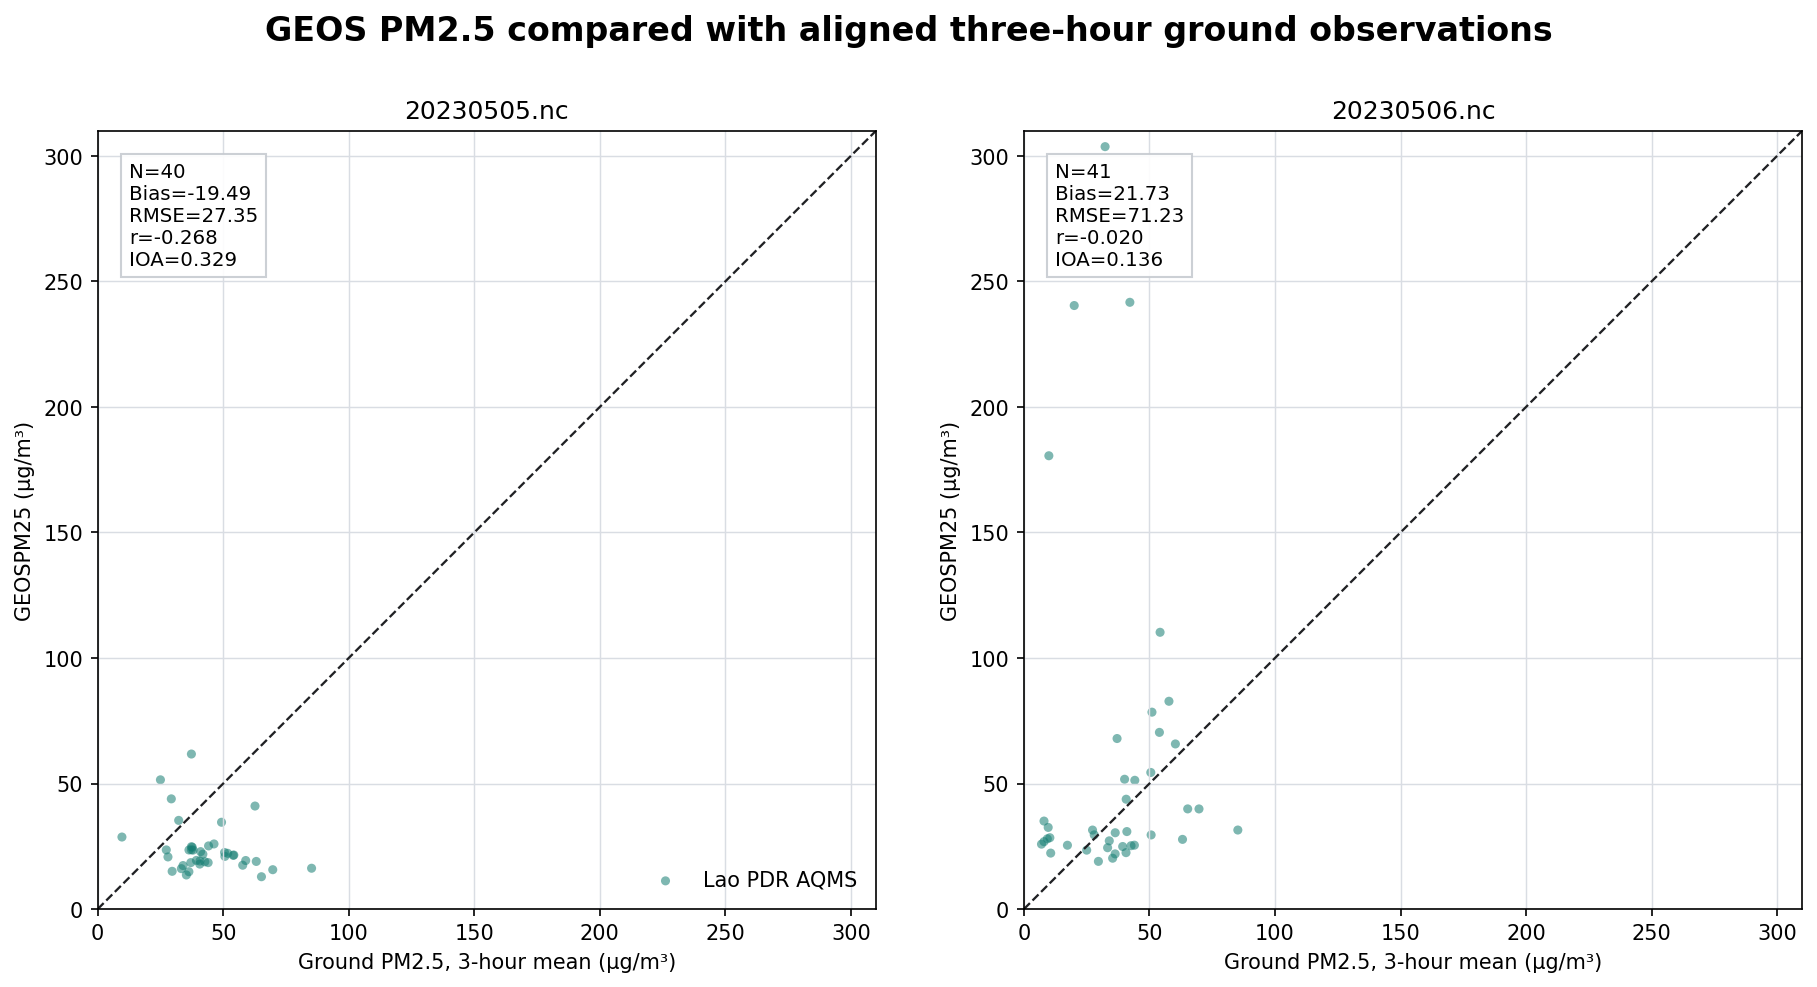

Matched comparison rows: 81
Stations represented: 2
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_ground_3h_comparison.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_ground_3h_metrics_by_file.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_ground_3h_scatter.png


,source_geos_file,N,mean_bias,rmse,r,ioa,observed_mean,geos_mean
0,20230505.nc,40.0,-19.494245,27.350608,-0.267536,0.329221,43.386667,23.892422
1,20230506.nc,41.0,21.730940,71.232562,-0.020067,0.136435,36.629268,58.360209


,source_geos_file,source_geos_path,forecast_reference_date_utc,valid_time_utc,lead_hours_from_reference_date,forecast_day,network,station_code,station_name,geos_lat_index,...,geos_grid_lon,geos_distance_km,GEOSPM25,ground_pm25_3h,n_obs,bin_start_utc,first_hour_utc,last_hour_utc,source_rows,observation_source_file
0,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 01:30:00+00:00,1.5,1,Lao PDR AQMS,AQMS02,Thakhek,50,...,104.6875,16.620459,41.043312,62.666667,3,2023-05-05 00:00:00+00:00,2023-05-05 00:00:00+00:00,2023-05-05 02:00:00+00:00,3,AQMS02.csv
1,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 04:30:00+00:00,4.5,1,Lao PDR AQMS,AQMS02,Thakhek,50,...,104.6875,16.620459,61.754840,37.333333,3,2023-05-05 03:00:00+00:00,2023-05-05 03:00:00+00:00,2023-05-05 05:00:00+00:00,3,AQMS02.csv
2,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 07:30:00+00:00,7.5,1,Lao PDR AQMS,AQMS02,Thakhek,50,...,104.6875,16.620459,51.484566,25.000000,3,2023-05-05 06:00:00+00:00,2023-05-05 06:00:00+00:00,2023-05-05 08:00:00+00:00,3,AQMS02.csv
3,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 10:30:00+00:00,10.5,1,Lao PDR AQMS,AQMS02,Thakhek,50,...,104.6875,16.620459,43.902360,29.333333,3,2023-05-05 09:00:00+00:00,2023-05-05 09:00:00+00:00,2023-05-05 11:00:00+00:00,3,AQMS02.csv
4,20230505.nc,{TRAINING_ROOT}/data/module2/geos/20230505.nc,2023-05-05 00:00:00+00:00,2023-05-05 13:30:00+00:00,13.5,1,Lao PDR AQMS,AQMS02,Thakhek,50,...,104.6875,16.620459,34.587970,49.333333,3,2023-05-05 12:00:00+00:00,2023-05-05 12:00:00+00:00,2023-05-05 14:00:00+00:00,3,AQMS02.csv


In [17]:
# --- What this cell does ---
# Joins GEOS and ground data using station code and UTC valid time.
# Calculates sample size, mean bias, RMSE, correlation, and original Willmott IOA.
# Creates initialization-specific scatterplots and saves the matched analysis table.
# --- End annotation ---

GEOS_COMPARISON_VARIABLE = "GEOSPM25"

geos_comparison_columns = [
    "source_geos_file",
    "source_geos_path",
    "forecast_reference_date_utc",
    "valid_time_utc",
    "lead_hours_from_reference_date",
    "forecast_day",
    "network",
    "station_code",
    "station_name",
    "geos_lat_index",
    "geos_lon_index",
    "geos_grid_index",
    "geos_grid_lat",
    "geos_grid_lon",
    "geos_distance_km",
    GEOS_COMPARISON_VARIABLE,
]

# Match on station and UTC valid time; initialization time remains a separate forecast attribute.
geos_ground_comparison = geos_collocated_wide[geos_comparison_columns].merge(
    ground_observations_3h[
        [
            "station_code",
            "valid_time_utc",
            "ground_pm25_3h",
            "n_obs",
            "bin_start_utc",
            "first_hour_utc",
            "last_hour_utc",
            "source_rows",
            "observation_source_file",
        ]
    ],
    on=["station_code", "valid_time_utc"],
    how="inner",
    validate="many_to_one",
)
geos_ground_comparison = geos_ground_comparison.loc[
    geos_ground_comparison["n_obs"].eq(3)
    & np.isfinite(geos_ground_comparison["ground_pm25_3h"])
    & np.isfinite(geos_ground_comparison[GEOS_COMPARISON_VARIABLE])
].copy()


def comparison_metrics(frame):
    observed = frame["ground_pm25_3h"].to_numpy(dtype=float)
    modeled = frame[GEOS_COMPARISON_VARIABLE].to_numpy(dtype=float)
    residual = modeled - observed
    observed_mean = observed.mean()
    # Original Willmott IOA uses squared error (j=2) and is bounded above by 1.
    denominator = np.sum(
        (np.abs(modeled - observed_mean) + np.abs(observed - observed_mean)) ** 2
    )
    ioa = 1.0 - np.sum(residual ** 2) / denominator if denominator > 0 else np.nan
    correlation = (
        np.corrcoef(observed, modeled)[0, 1]
        if len(observed) > 1 and observed.std() > 0 and modeled.std() > 0
        else np.nan
    )
    return pd.Series({
        "N": len(frame),
        "mean_bias": residual.mean(),
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "r": correlation,
        "ioa": ioa,
        "observed_mean": observed.mean(),
        "geos_mean": modeled.mean(),
    })


comparison_metrics_by_file = pd.DataFrame([
    {
        "source_geos_file": source_file,
        **comparison_metrics(file_data).to_dict(),
    }
    for source_file, file_data in geos_ground_comparison.groupby("source_geos_file", sort=True)
])

comparison_output = OUTPUT_DIR / "module2_geos_ground_3h_comparison.csv"
metrics_output = OUTPUT_DIR / "module2_geos_ground_3h_metrics_by_file.csv"
geos_ground_comparison.to_csv(comparison_output, index=False)
comparison_metrics_by_file.to_csv(metrics_output, index=False)

source_files = comparison_metrics_by_file["source_geos_file"].tolist()
all_plot_values = np.concatenate([
    geos_ground_comparison["ground_pm25_3h"].to_numpy(dtype=float),
    geos_ground_comparison[GEOS_COMPARISON_VARIABLE].to_numpy(dtype=float),
])
axis_max = max(10.0, np.ceil(np.nanmax(all_plot_values) / 10.0) * 10.0)

fig, axes = plt.subplots(1, len(source_files), figsize=(12.5, 6.4), dpi=150, squeeze=False)
network_colors = {"Thai PCD": "#d64f3c", "Lao PDR AQMS": "#147d72"}

for panel, source_file in enumerate(source_files):
    ax = axes[0, panel]
    panel_data = geos_ground_comparison.loc[
        geos_ground_comparison["source_geos_file"] == source_file
    ]
    for network, network_data in panel_data.groupby("network"):
        ax.scatter(
            network_data["ground_pm25_3h"],
            network_data[GEOS_COMPARISON_VARIABLE],
            s=19,
            alpha=0.55,
            color=network_colors.get(network, "#59636e"),
            edgecolors="none",
            label=network,
        )
    ax.plot([0, axis_max], [0, axis_max], color="#202124", linestyle="--", linewidth=1.1)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(color="#d9dde3", linewidth=0.7)
    ax.set_xlabel("Ground PM2.5, 3-hour mean (µg/m³)")
    ax.set_ylabel(f"{GEOS_COMPARISON_VARIABLE} (µg/m³)")
    ax.set_title(source_file)

    metric = comparison_metrics_by_file.loc[
        comparison_metrics_by_file["source_geos_file"] == source_file
    ].iloc[0]
    metric_text = (
        f"N={int(metric['N']):,}\n"
        f"Bias={metric['mean_bias']:.2f}\n"
        f"RMSE={metric['rmse']:.2f}\n"
        f"r={metric['r']:.3f}\n"
        f"IOA={metric['ioa']:.3f}"
    )
    ax.text(
        0.04,
        0.96,
        metric_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9.5,
        bbox={"boxstyle": "square,pad=0.4", "facecolor": "white", "edgecolor": "#c7cbd1", "alpha": 0.9},
    )
    if panel == 0:
        ax.legend(frameon=False, loc="lower right")

fig.suptitle("GEOS PM2.5 compared with aligned three-hour ground observations", fontsize=16, fontweight="semibold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
comparison_figure = OUTPUT_DIR / "module2_geos_ground_3h_scatter.png"
fig.savefig(comparison_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print("Matched comparison rows:", f"{len(geos_ground_comparison):,}")
print("Stations represented:", geos_ground_comparison["station_code"].nunique())
print("Saved:", comparison_output)
print("Saved:", metrics_output)
print("Saved:", comparison_figure)
display(comparison_metrics_by_file)
display(geos_ground_comparison.head())


### 4.4 Inspect one Lao PDR AQMS station as a time series

The scatterplots summarize agreement but do not show temporal behavior. This view plots one selected Lao PDR AQMS station through the two forecast cycles:

- quality-controlled three-hour ground observations appear in gray;
- each GEOS NetCDF source file appears as a separate forecast line; and
- missing ground intervals remain gaps rather than being filled or interpolated.

Change `TIMESERIES_STATION_CODE` to another Lao PDR AQMS station represented in the comparison window.


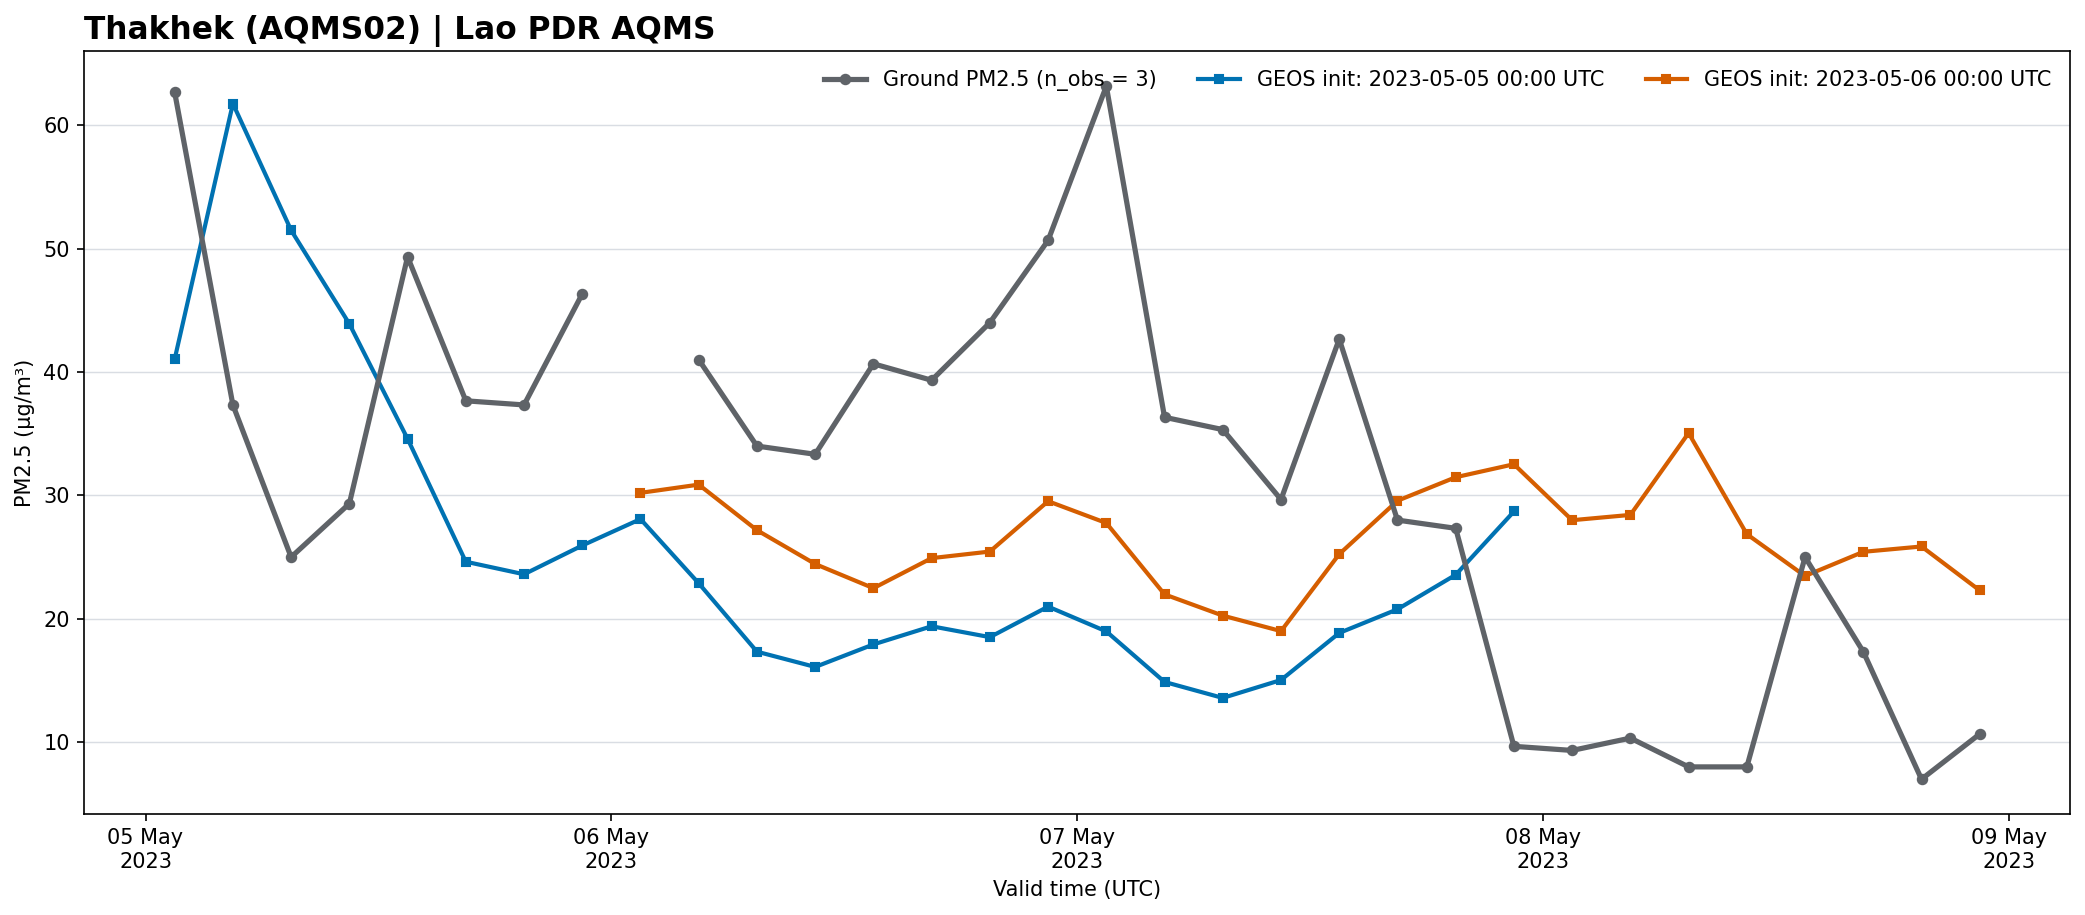

Station: AQMS02 | Thakhek
Ground timestamps: 31
GEOS initialization times: [Timestamp('2023-05-05 00:00:00+0000', tz='UTC'), Timestamp('2023-05-06 00:00:00+0000', tz='UTC')]
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_AQMS02_geos_ground_3h_timeseries.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_AQMS02_geos_ground_3h_timeseries.png


,valid_time_utc,initialization_time_utc,series,source,source_geos_file,pm25_ug_m3,n_obs
31,2023-05-05 01:30:00+00:00,2023-05-05 00:00:00+00:00,GEOS,GEOS init: 2023-05-05 00:00 UTC,20230505.nc,41.043312,NaN
0,2023-05-05 01:30:00+00:00,NaT,Ground observation,AQMS02.csv,<NA>,62.666667,3.0
32,2023-05-05 04:30:00+00:00,2023-05-05 00:00:00+00:00,GEOS,GEOS init: 2023-05-05 00:00 UTC,20230505.nc,61.754840,NaN
1,2023-05-05 04:30:00+00:00,NaT,Ground observation,AQMS02.csv,<NA>,37.333333,3.0
33,2023-05-05 07:30:00+00:00,2023-05-05 00:00:00+00:00,GEOS,GEOS init: 2023-05-05 00:00 UTC,20230505.nc,51.484566,NaN
2,2023-05-05 07:30:00+00:00,NaT,Ground observation,AQMS02.csv,<NA>,25.000000,3.0
34,2023-05-05 10:30:00+00:00,2023-05-05 00:00:00+00:00,GEOS,GEOS init: 2023-05-05 00:00 UTC,20230505.nc,43.902360,NaN
3,2023-05-05 10:30:00+00:00,NaT,Ground observation,AQMS02.csv,<NA>,29.333333,3.0
35,2023-05-05 13:30:00+00:00,2023-05-05 00:00:00+00:00,GEOS,GEOS init: 2023-05-05 00:00 UTC,20230505.nc,34.587970,NaN
4,2023-05-05 13:30:00+00:00,NaT,Ground observation,AQMS02.csv,<NA>,49.333333,3.0


In [18]:
# --- What this cell does ---
# Selects one Lao PDR AQMS station with matched data.
# Plots observations and each GEOS initialization on a common UTC timeline.
# Reindexing preserves missing observations as gaps instead of drawing misleading connections.
# --- End annotation ---

import matplotlib.dates as mdates
from datetime import timezone

available_aqms_stations = sorted(
    geos_ground_comparison.loc[
        geos_ground_comparison["network"] == "Lao PDR AQMS",
        "station_code",
    ].unique()
)
if not available_aqms_stations:
    raise ValueError("No Lao PDR AQMS stations have matched observations in this GEOS window.")

TIMESERIES_STATION_CODE = available_aqms_stations[0]
timeseries_station = station_summary.loc[
    station_summary["station_code"] == TIMESERIES_STATION_CODE
].iloc[0]

ground_series = (
    ground_observations_3h.loc[
        ground_observations_3h["station_code"] == TIMESERIES_STATION_CODE,
        ["valid_time_utc", "ground_pm25_3h", "n_obs"],
    ]
    .drop_duplicates("valid_time_utc")
    .set_index("valid_time_utc")
    .sort_index()
)
model_series = geos_collocated_wide.loc[
    geos_collocated_wide["station_code"] == TIMESERIES_STATION_CODE,
    ["source_geos_file", "forecast_reference_date_utc", "valid_time_utc", GEOS_COMPARISON_VARIABLE],
].copy()

timeline = pd.date_range(
    geos_collocated_wide["valid_time_utc"].min(),
    geos_collocated_wide["valid_time_utc"].max(),
    freq="3h",
    tz="UTC",
)
# Reindex to every expected three-hour midpoint so absent observations appear as NaN gaps.
ground_plot = ground_series.reindex(timeline)

fig, ax = plt.subplots(figsize=(14, 6.2), dpi=150)
ax.plot(
    timeline,
    ground_plot["ground_pm25_3h"],
    color="#5f6368",
    linewidth=2.5,
    marker="o",
    markersize=4.5,
    label="Ground PM2.5 (n_obs = 3)",
    zorder=4,
)

forecast_colors = ["#0072b2", "#d55e00", "#6f42c1", "#009e73"]
for color, (source_file, source_data) in zip(
    forecast_colors,
    model_series.groupby("source_geos_file", sort=True),
):
    initialization_time = pd.to_datetime(
        source_data["forecast_reference_date_utc"].iloc[0], utc=True
    )
    source_plot = (
        source_data.set_index("valid_time_utc")[[GEOS_COMPARISON_VARIABLE]]
        .sort_index()
        .reindex(timeline)
    )
    ax.plot(
        timeline,
        source_plot[GEOS_COMPARISON_VARIABLE],
        color=color,
        linewidth=2.0,
        marker="s",
        markersize=3.8,
        label=f"GEOS init: {initialization_time:%Y-%m-%d %H:%M} UTC",
        zorder=3,
    )

ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Valid time (UTC)")
ax.set_title(
    f"{timeseries_station['station_name']} ({TIMESERIES_STATION_CODE}) | Lao PDR AQMS",
    loc="left",
    fontsize=15,
    fontweight="semibold",
)
ax.grid(axis="y", color="#d9dde3", linewidth=0.7)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%Y", tz=timezone.utc))
ax.legend(frameon=False, ncol=3, loc="upper right")
fig.tight_layout()

timeseries_figure = OUTPUT_DIR / f"module2_{TIMESERIES_STATION_CODE}_geos_ground_3h_timeseries.png"
fig.savefig(timeseries_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

ground_export = ground_series.reset_index().rename(columns={"index": "valid_time_utc"})
ground_export["series"] = "Ground observation"
ground_export["source"] = timeseries_station["source_file"]
ground_export["initialization_time_utc"] = pd.NaT
ground_export["source_geos_file"] = pd.NA
ground_export["pm25_ug_m3"] = ground_export["ground_pm25_3h"]

model_export = model_series.rename(columns={GEOS_COMPARISON_VARIABLE: "pm25_ug_m3"})
model_export["series"] = "GEOS"
model_export["initialization_time_utc"] = pd.to_datetime(
    model_export["forecast_reference_date_utc"], utc=True
)
model_export["source"] = model_export["initialization_time_utc"].dt.strftime(
    "GEOS init: %Y-%m-%d %H:%M UTC"
)
model_export["n_obs"] = np.nan

export_columns = [
    "valid_time_utc",
    "initialization_time_utc",
    "series",
    "source",
    "source_geos_file",
    "pm25_ug_m3",
    "n_obs",
]
timeseries_export = pd.concat(
    [
        ground_export[export_columns],
        model_export[export_columns],
    ],
    ignore_index=True,
).sort_values(["valid_time_utc", "series", "source"])
timeseries_output = OUTPUT_DIR / f"module2_{TIMESERIES_STATION_CODE}_geos_ground_3h_timeseries.csv"
timeseries_export.to_csv(timeseries_output, index=False)

print("Station:", TIMESERIES_STATION_CODE, "|", timeseries_station["station_name"])
print("Ground timestamps:", ground_series["ground_pm25_3h"].notna().sum())
print(
    "GEOS initialization times:",
    sorted(pd.to_datetime(model_series["forecast_reference_date_utc"], utc=True).unique()),
)
print("Saved:", timeseries_output)
print("Saved:", timeseries_figure)
display(timeseries_export.head(12))


## Section 5: Analyze the saved collocated dataset

This section begins with the saved model-observation table. It does not reopen the NetCDF files. We verify the analysis sample, score GEOS by station and forecast day, and inspect how error changes with observed PM2.5 and forecast lead.


### 5.1 Load and verify the analysis-ready records

Only complete ground averages (`n_obs = 3`) and finite PM2.5 values from 1 through 1,000 µg/m³ are retained. The initialization timestamp remains separate from valid time and forecast lead.


In [19]:
# --- What this cell does ---
# Reloads the saved collocated comparison table without reopening NetCDF files.
# Applies the final n_obs and PM2.5 range checks and calculates GEOS-minus-ground error.
# --- End annotation ---

COLLOCATED_ANALYSIS_FILE = OUTPUT_DIR / "module2_geos_ground_3h_comparison.csv"

collocated_analysis = pd.read_csv(
    COLLOCATED_ANALYSIS_FILE,
    parse_dates=[
        "forecast_reference_date_utc",
        "valid_time_utc",
        "bin_start_utc",
        "first_hour_utc",
        "last_hour_utc",
    ],
)
collocated_analysis = collocated_analysis.rename(
    columns={"forecast_reference_date_utc": "initialization_time_utc"}
)

# Reapply final analysis rules after loading a saved file; never assume prior filtering is enough.
analysis_mask = (
    collocated_analysis["n_obs"].eq(3)
    & collocated_analysis["ground_pm25_3h"].between(1, 1000, inclusive="both")
    & collocated_analysis["GEOSPM25"].between(1, 1000, inclusive="both")
    & np.isfinite(collocated_analysis["ground_pm25_3h"])
    & np.isfinite(collocated_analysis["GEOSPM25"])
)
collocated_analysis = collocated_analysis.loc[analysis_mask].copy()
collocated_analysis["error_geos_minus_ground"] = (
    collocated_analysis["GEOSPM25"] - collocated_analysis["ground_pm25_3h"]
)
collocated_analysis["absolute_error"] = collocated_analysis[
    "error_geos_minus_ground"
].abs()

analysis_inventory = (
    collocated_analysis.groupby(
        ["station_code", "station_name", "forecast_day"], as_index=False
    )
    .agg(
        N=("valid_time_utc", "size"),
        first_valid_time_utc=("valid_time_utc", "min"),
        last_valid_time_utc=("valid_time_utc", "max"),
        initialization_count=("initialization_time_utc", "nunique"),
    )
)

assert collocated_analysis["n_obs"].eq(3).all()
assert collocated_analysis["ground_pm25_3h"].between(1, 1000).all()
assert collocated_analysis["GEOSPM25"].between(1, 1000).all()

print("Input:", COLLOCATED_ANALYSIS_FILE)
print("Analysis records:", f"{len(collocated_analysis):,}")
print("Stations:", collocated_analysis["station_code"].nunique())
print("Initialization times (UTC):")
for initialization_time in sorted(collocated_analysis["initialization_time_utc"].unique()):
    print(" ", pd.Timestamp(initialization_time).strftime("%Y-%m-%d %H:%M UTC"))
display(analysis_inventory)


Input: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_geos_ground_3h_comparison.csv
Analysis records: 81
Stations: 2
Initialization times (UTC):
  2023-05-05 00:00 UTC
  2023-05-06 00:00 UTC


,station_code,station_name,forecast_day,N,first_valid_time_utc,last_valid_time_utc,initialization_count
0,AQMS02,Thakhek,1,15,2023-05-05 01:30:00+00:00,2023-05-06 22:30:00+00:00,2
1,AQMS02,Thakhek,2,15,2023-05-06 04:30:00+00:00,2023-05-07 22:30:00+00:00,2
2,AQMS02,Thakhek,3,16,2023-05-07 01:30:00+00:00,2023-05-08 22:30:00+00:00,2
3,AQMS05,Luang Namtha,1,12,2023-05-05 01:30:00+00:00,2023-05-06 22:30:00+00:00,2
4,AQMS05,Luang Namtha,2,11,2023-05-06 01:30:00+00:00,2023-05-07 22:30:00+00:00,2
5,AQMS05,Luang Namtha,3,12,2023-05-07 01:30:00+00:00,2023-05-08 22:30:00+00:00,2


### 5.2 Build a station-by-forecast-day scorecard

The four panels answer different questions: IOA measures agreement, correlation measures co-variation, RMSE measures typical error magnitude, and mean bias shows whether GEOS is systematically high or low. Each cell also reports its sample size.


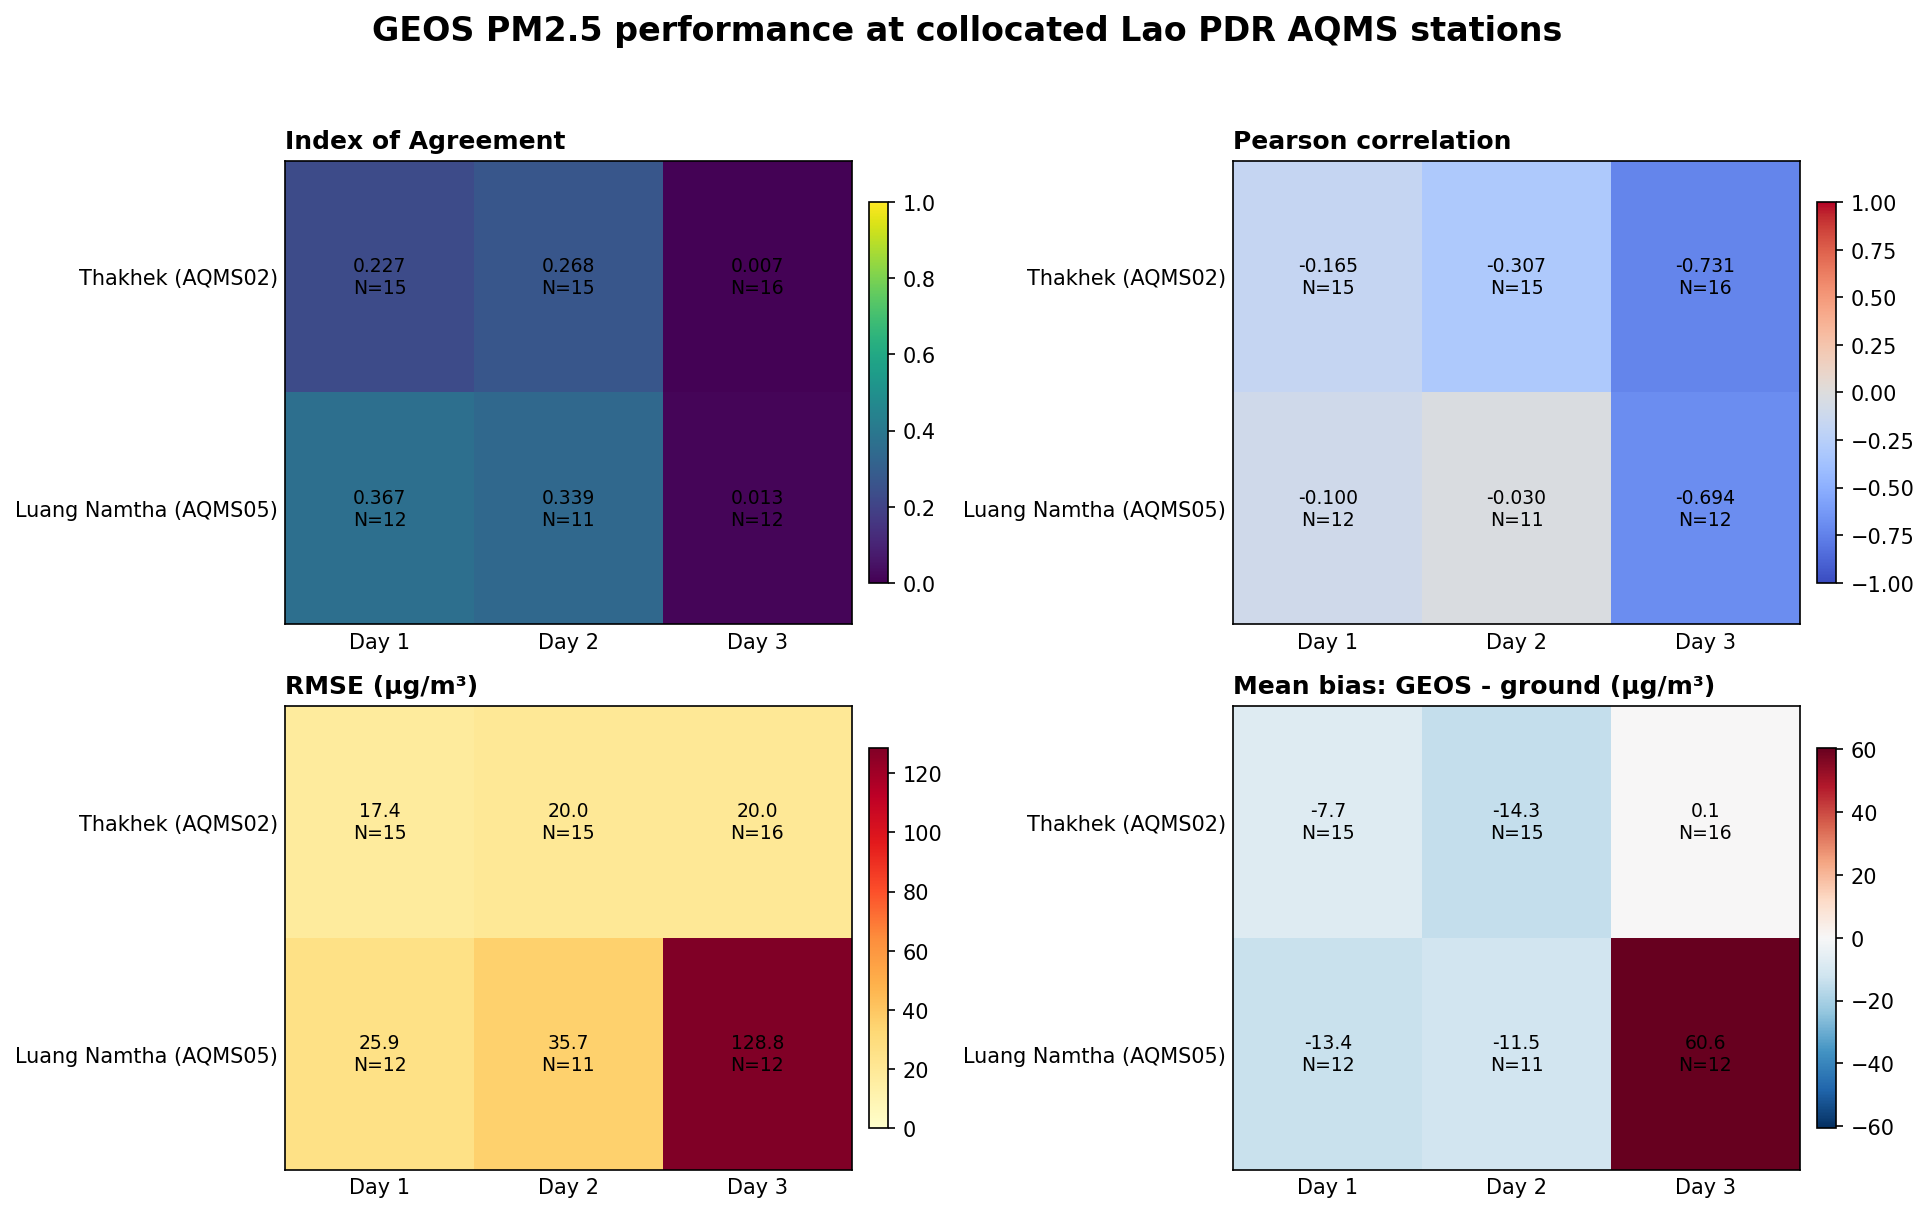

Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_collocated_metrics_by_station_forecast_day.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_collocated_station_forecast_day_scorecard.png


,station_code,station_name,forecast_day,N,observed_mean,geos_mean,mean_bias,mae,rmse,r,ioa
0,AQMS02,Thakhek,1,15.0,40.533,32.789,-7.745,16.475,17.372,-0.165,0.227
1,AQMS02,Thakhek,2,15.0,37.011,22.731,-14.280,18.090,19.990,-0.307,0.268
2,AQMS02,Thakhek,3,16.0,22.990,23.111,0.121,17.414,20.027,-0.731,0.007
3,AQMS05,Luang Namtha,1,12.0,48.614,35.208,-13.405,20.889,25.901,-0.100,0.367
4,AQMS05,Luang Namtha,2,11.0,54.094,42.615,-11.479,29.743,35.688,-0.030,0.339
5,AQMS05,Luang Namtha,3,12.0,43.989,104.553,60.564,90.481,128.764,-0.694,0.013


In [20]:
# --- What this cell does ---
# Calculates performance metrics for every station and forecast-day combination.
# Pivots the metric table into four annotated heatmaps with sample size in each cell.
# --- End annotation ---

def collocated_performance_metrics(frame):
    observed = frame["ground_pm25_3h"].to_numpy(dtype=float)
    modeled = frame["GEOSPM25"].to_numpy(dtype=float)
    error = modeled - observed
    observed_mean = observed.mean()
    # The IOA denominator measures the largest plausible departure around the observed mean.
    ioa_denominator = np.sum(
        (np.abs(modeled - observed_mean) + np.abs(observed - observed_mean)) ** 2
    )
    correlation = (
        np.corrcoef(observed, modeled)[0, 1]
        if len(frame) > 1 and observed.std() > 0 and modeled.std() > 0
        else np.nan
    )
    return pd.Series({
        "N": len(frame),
        "observed_mean": observed.mean(),
        "geos_mean": modeled.mean(),
        "mean_bias": error.mean(),
        "mae": np.abs(error).mean(),
        "rmse": np.sqrt(np.mean(error ** 2)),
        "r": correlation,
        "ioa": 1.0 - np.sum(error ** 2) / ioa_denominator
        if ioa_denominator > 0
        else np.nan,
    })


scorecard_rows = []
for (station_code, station_name, forecast_day), group in collocated_analysis.groupby(
    ["station_code", "station_name", "forecast_day"], sort=True
):
    scorecard_rows.append({
        "station_code": station_code,
        "station_name": station_name,
        "forecast_day": int(forecast_day),
        **collocated_performance_metrics(group).to_dict(),
    })

station_day_metrics = pd.DataFrame(scorecard_rows).sort_values(
    ["station_code", "forecast_day"]
)
station_day_metrics_output = OUTPUT_DIR / "module2_collocated_metrics_by_station_forecast_day.csv"
station_day_metrics.to_csv(station_day_metrics_output, index=False)

station_labels = (
    station_day_metrics[["station_code", "station_name"]]
    .drop_duplicates()
    .assign(label=lambda frame: frame["station_name"] + " (" + frame["station_code"] + ")")
)
station_order = station_labels["station_code"].tolist()
label_order = station_labels["label"].tolist()
day_order = sorted(station_day_metrics["forecast_day"].unique())
n_table = station_day_metrics.pivot(
    index="station_code", columns="forecast_day", values="N"
).reindex(index=station_order, columns=day_order)

panel_settings = [
    ("ioa", "Index of Agreement", "viridis", 0.0, 1.0, ".3f"),
    ("r", "Pearson correlation", "coolwarm", -1.0, 1.0, ".3f"),
    ("rmse", "RMSE (µg/m³)", "YlOrRd", 0.0, None, ".1f"),
    ("mean_bias", "Mean bias: GEOS - ground (µg/m³)", "RdBu_r", None, None, ".1f"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8.2), dpi=150)
for ax, (metric, title, color_map, lower, upper, number_format) in zip(
    axes.ravel(), panel_settings
):
    metric_table = station_day_metrics.pivot(
        index="station_code", columns="forecast_day", values=metric
    ).reindex(index=station_order, columns=day_order)
    values = metric_table.to_numpy(dtype=float)
    if metric == "mean_bias":
        color_limit = max(1.0, np.nanmax(np.abs(values)))
        lower, upper = -color_limit, color_limit
    image = ax.imshow(values, cmap=color_map, vmin=lower, vmax=upper, aspect="auto")
    ax.set_title(title, loc="left", fontsize=12, fontweight="semibold")
    ax.set_xticks(range(len(day_order)), [f"Day {day}" for day in day_order])
    ax.set_yticks(range(len(label_order)), label_order)
    ax.tick_params(length=0)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            sample_size = n_table.iloc[row, column]
            label = "NA" if not np.isfinite(value) else f"{value:{number_format}}"
            if np.isfinite(sample_size):
                label += f"\nN={int(sample_size)}"
            ax.text(column, row, label, ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, shrink=0.82, pad=0.025)

fig.suptitle(
    "GEOS PM2.5 performance at collocated Lao PDR AQMS stations",
    fontsize=16,
    fontweight="semibold",
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
scorecard_figure = OUTPUT_DIR / "module2_collocated_station_forecast_day_scorecard.png"
fig.savefig(scorecard_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", station_day_metrics_output)
print("Saved:", scorecard_figure)
display(station_day_metrics.round(3))


### 5.3 Diagnose error by concentration and forecast day

Residuals are defined as `GEOS - ground`: positive values indicate overestimation and negative values indicate underestimation. Concentration bins reveal whether bias changes between relatively clean and polluted conditions; the forecast-day panel shows how the error distribution evolves with lead time.


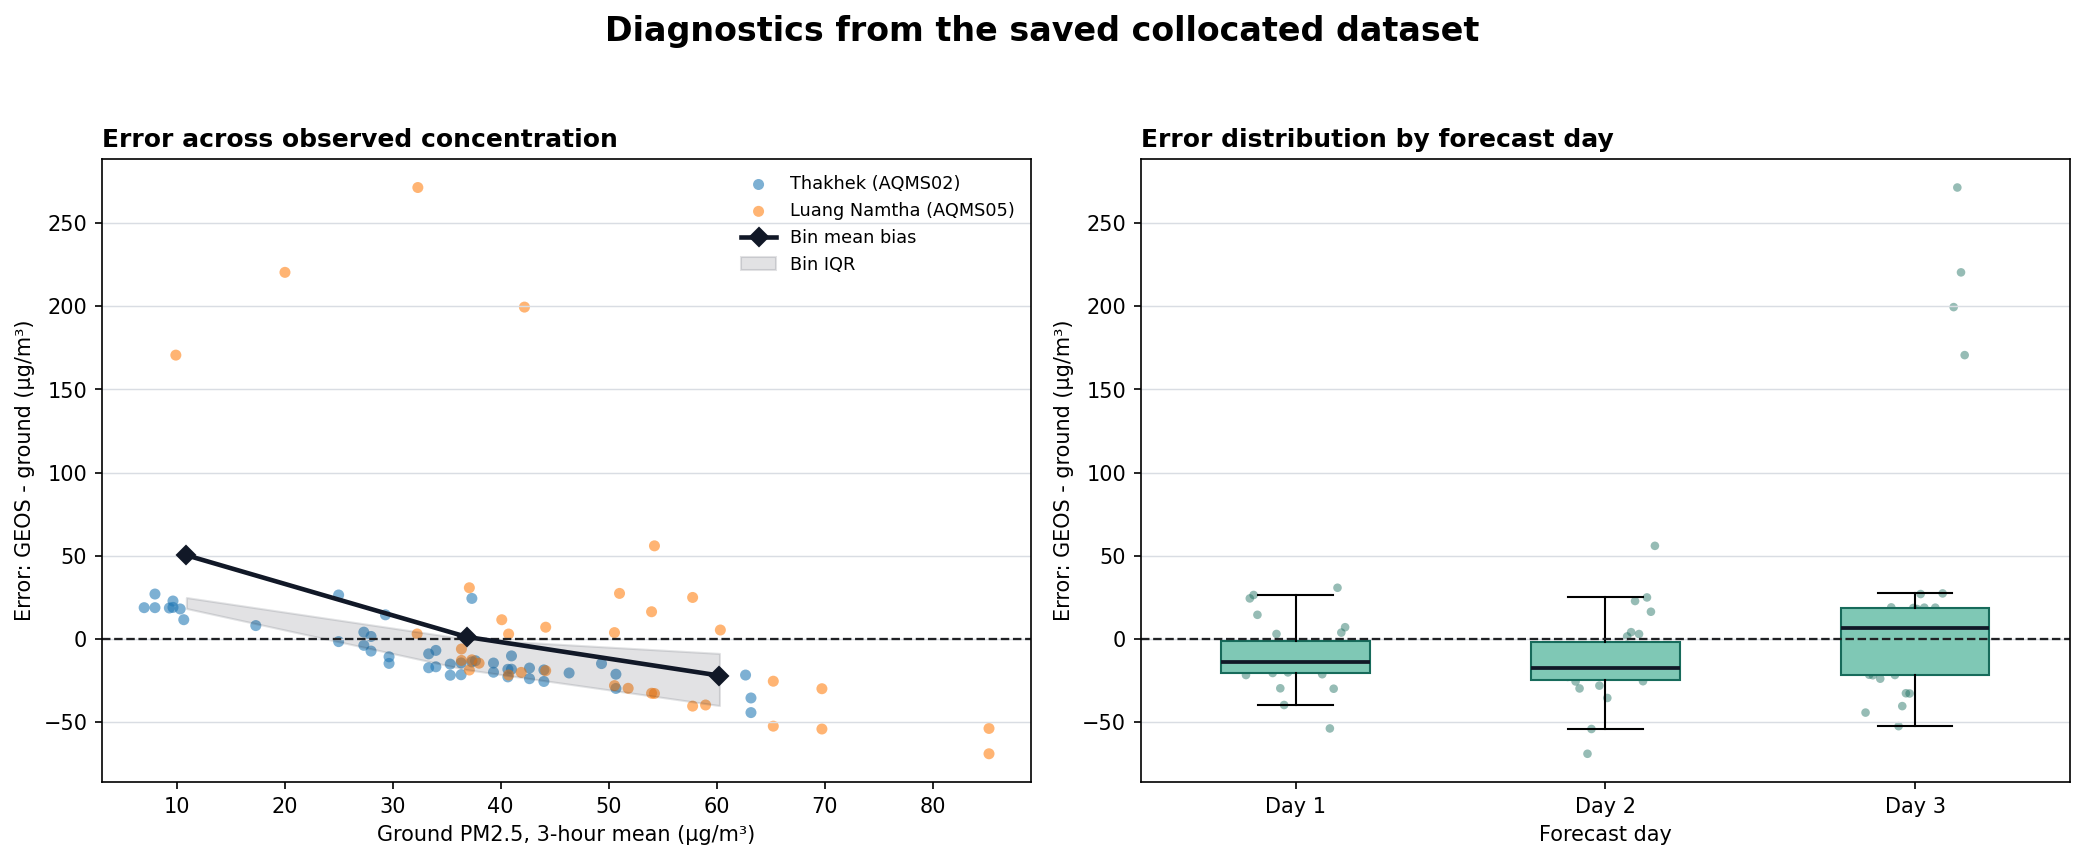

Lowest RMSE: day 1 (21.58 µg/m³)
Highest IOA: day 2 (0.463)
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_collocated_bias_by_observed_concentration.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_collocated_metrics_by_forecast_day.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_collocated_residual_diagnostics.png


,forecast_day,N,observed_mean,geos_mean,mean_bias,mae,rmse,r,ioa
0,1,27.0,44.125,33.864,-10.261,18.437,21.583,-0.086,0.315
1,2,26.0,44.238,31.143,-13.095,23.020,27.738,0.196,0.463
2,3,28.0,31.989,58.015,26.025,48.729,85.644,-0.070,0.093


,observed_pm25_bin,N,observed_mean,mean_bias,median_bias,bias_q25,bias_q75,rmse
0,1-<25,11,10.906,50.375,18.862,18.373,24.958,85.744
1,25-<50,47,36.841,1.317,-13.724,-18.367,0.019,51.663
2,50-<100,23,60.251,-21.948,-29.677,-39.958,-8.628,37.091
3,100-<200,0,NaN,NaN,NaN,NaN,NaN,NaN
4,200-1000,0,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# --- What this cell does ---
# Bins records by observed PM2.5 to diagnose concentration-dependent error.
# Compares residual distributions across forecast Days 1–3 and saves summary tables.
# --- End annotation ---

concentration_edges = [1, 25, 50, 100, 200, 1000]
concentration_labels = ["1-<25", "25-<50", "50-<100", "100-<200", "200-1000"]
collocated_analysis["observed_pm25_bin"] = pd.cut(
    collocated_analysis["ground_pm25_3h"],
    bins=concentration_edges,
    labels=concentration_labels,
    right=False,
    include_lowest=True,
)

residual_by_concentration = (
    collocated_analysis.dropna(subset=["observed_pm25_bin"])
    .groupby("observed_pm25_bin", observed=False, as_index=False)
    .agg(
        N=("error_geos_minus_ground", "size"),
        observed_mean=("ground_pm25_3h", "mean"),
        mean_bias=("error_geos_minus_ground", "mean"),
        median_bias=("error_geos_minus_ground", "median"),
        bias_q25=("error_geos_minus_ground", lambda values: values.quantile(0.25)),
        bias_q75=("error_geos_minus_ground", lambda values: values.quantile(0.75)),
        rmse=("error_geos_minus_ground", lambda values: np.sqrt(np.mean(values ** 2))),
    )
)
residual_summary_output = OUTPUT_DIR / "module2_collocated_bias_by_observed_concentration.csv"
residual_by_concentration.to_csv(residual_summary_output, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), dpi=150)

for station_code, station_data in collocated_analysis.groupby("station_code", sort=True):
    station_name = station_data["station_name"].iloc[0]
    axes[0].scatter(
        station_data["ground_pm25_3h"],
        station_data["error_geos_minus_ground"],
        s=28,
        alpha=0.58,
        edgecolors="none",
        label=f"{station_name} ({station_code})",
    )
axes[0].axhline(0, color="#202124", linestyle="--", linewidth=1.1)
axes[0].plot(
    residual_by_concentration["observed_mean"],
    residual_by_concentration["mean_bias"],
    color="#111827",
    marker="D",
    linewidth=2.2,
    label="Bin mean bias",
)
axes[0].fill_between(
    residual_by_concentration["observed_mean"],
    residual_by_concentration["bias_q25"],
    residual_by_concentration["bias_q75"],
    color="#111827",
    alpha=0.12,
    label="Bin IQR",
)
axes[0].set_xlabel("Ground PM2.5, 3-hour mean (µg/m³)")
axes[0].set_ylabel("Error: GEOS - ground (µg/m³)")
axes[0].set_title("Error across observed concentration", loc="left", fontweight="semibold")
axes[0].grid(axis="y", color="#d9dde3", linewidth=0.7)
axes[0].legend(frameon=False, fontsize=8.5)

day_groups = [
    collocated_analysis.loc[
        collocated_analysis["forecast_day"] == day, "error_geos_minus_ground"
    ].to_numpy()
    for day in day_order
]
box = axes[1].boxplot(
    day_groups,
    positions=range(1, len(day_order) + 1),
    widths=0.48,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#111827", "linewidth": 1.8},
)
for patch in box["boxes"]:
    patch.set_facecolor("#7fc8b5")
    patch.set_edgecolor("#176b5b")
for day_position, day_values in enumerate(day_groups, start=1):
    jitter = np.linspace(-0.16, 0.16, len(day_values)) if len(day_values) else []
    axes[1].scatter(
        day_position + jitter,
        day_values,
        s=17,
        color="#176b5b",
        alpha=0.45,
        edgecolors="none",
    )
axes[1].axhline(0, color="#202124", linestyle="--", linewidth=1.1)
axes[1].set_xticks(range(1, len(day_order) + 1), [f"Day {day}" for day in day_order])
axes[1].set_xlabel("Forecast day")
axes[1].set_ylabel("Error: GEOS - ground (µg/m³)")
axes[1].set_title("Error distribution by forecast day", loc="left", fontweight="semibold")
axes[1].grid(axis="y", color="#d9dde3", linewidth=0.7)

fig.suptitle("Diagnostics from the saved collocated dataset", fontsize=16, fontweight="semibold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
residual_figure = OUTPUT_DIR / "module2_collocated_residual_diagnostics.png"
fig.savefig(residual_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

forecast_day_metrics = pd.DataFrame([
    {"forecast_day": int(day), **collocated_performance_metrics(day_data).to_dict()}
    for day, day_data in collocated_analysis.groupby("forecast_day", sort=True)
])
forecast_day_metrics_output = OUTPUT_DIR / "module2_collocated_metrics_by_forecast_day.csv"
forecast_day_metrics.to_csv(forecast_day_metrics_output, index=False)

best_rmse_day = forecast_day_metrics.loc[forecast_day_metrics["rmse"].idxmin()]
best_ioa_day = forecast_day_metrics.loc[forecast_day_metrics["ioa"].idxmax()]
print(
    f"Lowest RMSE: day {int(best_rmse_day['forecast_day'])} "
    f"({best_rmse_day['rmse']:.2f} µg/m³)"
)
print(
    f"Highest IOA: day {int(best_ioa_day['forecast_day'])} "
    f"({best_ioa_day['ioa']:.3f})"
)
print("Saved:", residual_summary_output)
print("Saved:", forecast_day_metrics_output)
print("Saved:", residual_figure)
display(forecast_day_metrics.round(3))
display(residual_by_concentration.round(3))


## Section 6: Full-period AQMS scatter matrix

The two-file example is useful for tracing the workflow, but it is too short
for station-level evaluation. This section loads a compact, analysis-ready
table prepared from the full archive with the same UTC alignment and QA/QC
rules used above.


### 6.1 Load and verify the compact AQMS evaluation table

The bundled table retains station identity, initialization time, valid time,
forecast day, complete three-hour observations (`n_obs = 3`), and GEOS PM2.5.
Loading the compact product makes the participant workflow reproducible without
distributing the multi-gigabyte intermediate archive.


In [ ]:
# --- What this cell does ---
# Loads the compact full-period Lao PDR AQMS evaluation table.
# Reapplies n_obs and concentration checks, removes duplicate forecast records,
# and saves a working copy under the participant output directory.
# --- End annotation ---

FULL_EVALUATION_FILE = (
    PROJECT_ROOT / "data" / "module2" / "full_period_aqms_geos_evaluation.csv"
)
full_aqms_evaluation = pd.read_csv(
    FULL_EVALUATION_FILE,
    parse_dates=["initialization_time_utc", "datetime_utc"],
)

valid = (
    full_aqms_evaluation["network"].eq("Lao PDR AQMS")
    & full_aqms_evaluation["station_code"].astype(str).str.match(r"^AQMS\d{2}$")
    & pd.to_numeric(full_aqms_evaluation["obs_n_obs"], errors="coerce").eq(3)
    & pd.to_numeric(full_aqms_evaluation["observed_pm25"], errors="coerce").between(1, 1000)
    & pd.to_numeric(full_aqms_evaluation["GEOSPM25"], errors="coerce").between(1, 1000)
)
full_aqms_evaluation = full_aqms_evaluation.loc[valid].copy()

deduplication_key = [
    "station_code", "forecast_day", "initialization_time_utc", "datetime_utc"
]
rows_before = len(full_aqms_evaluation)
full_aqms_evaluation = full_aqms_evaluation.drop_duplicates(
    deduplication_key, keep="last"
).reset_index(drop=True)
duplicate_rows_removed = rows_before - len(full_aqms_evaluation)

compact_aqms_output = OUTPUT_DIR / "module2_full_period_aqms_geos_evaluation.csv"
full_aqms_evaluation.to_csv(compact_aqms_output, index=False)

aqms_station_metadata = (
    full_aqms_evaluation[["station_code", "station_name"]]
    .drop_duplicates("station_code")
    .sort_values("station_code")
    .reset_index(drop=True)
)
aqms_codes = [f"AQMS{number:02d}" for number in range(1, 15)]
availability = (
    full_aqms_evaluation.groupby(["station_code", "forecast_day"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=aqms_codes, columns=[1, 2, 3], fill_value=0)
)
availability.columns = [f"Day {day}" for day in availability.columns]

print("Source:", FULL_EVALUATION_FILE)
print("Compact AQMS records:", f"{len(full_aqms_evaluation):,}")
print("Duplicate records removed:", f"{duplicate_rows_removed:,}")
print("Stations represented:", full_aqms_evaluation["station_code"].nunique(), "of 14")
print("Working copy:", compact_aqms_output)
display(availability)


### 6.2 Compare GEOS and observations across every station and forecast day

All panels use a common 1:1 axis. Point color represents local point density, which keeps both the main concentration cluster and sparse high-value observations visible. Metrics use the complete QA/QC-valid range of 1–1,000 µg/m³ even when the common display limit is based on the 99.5th percentile.


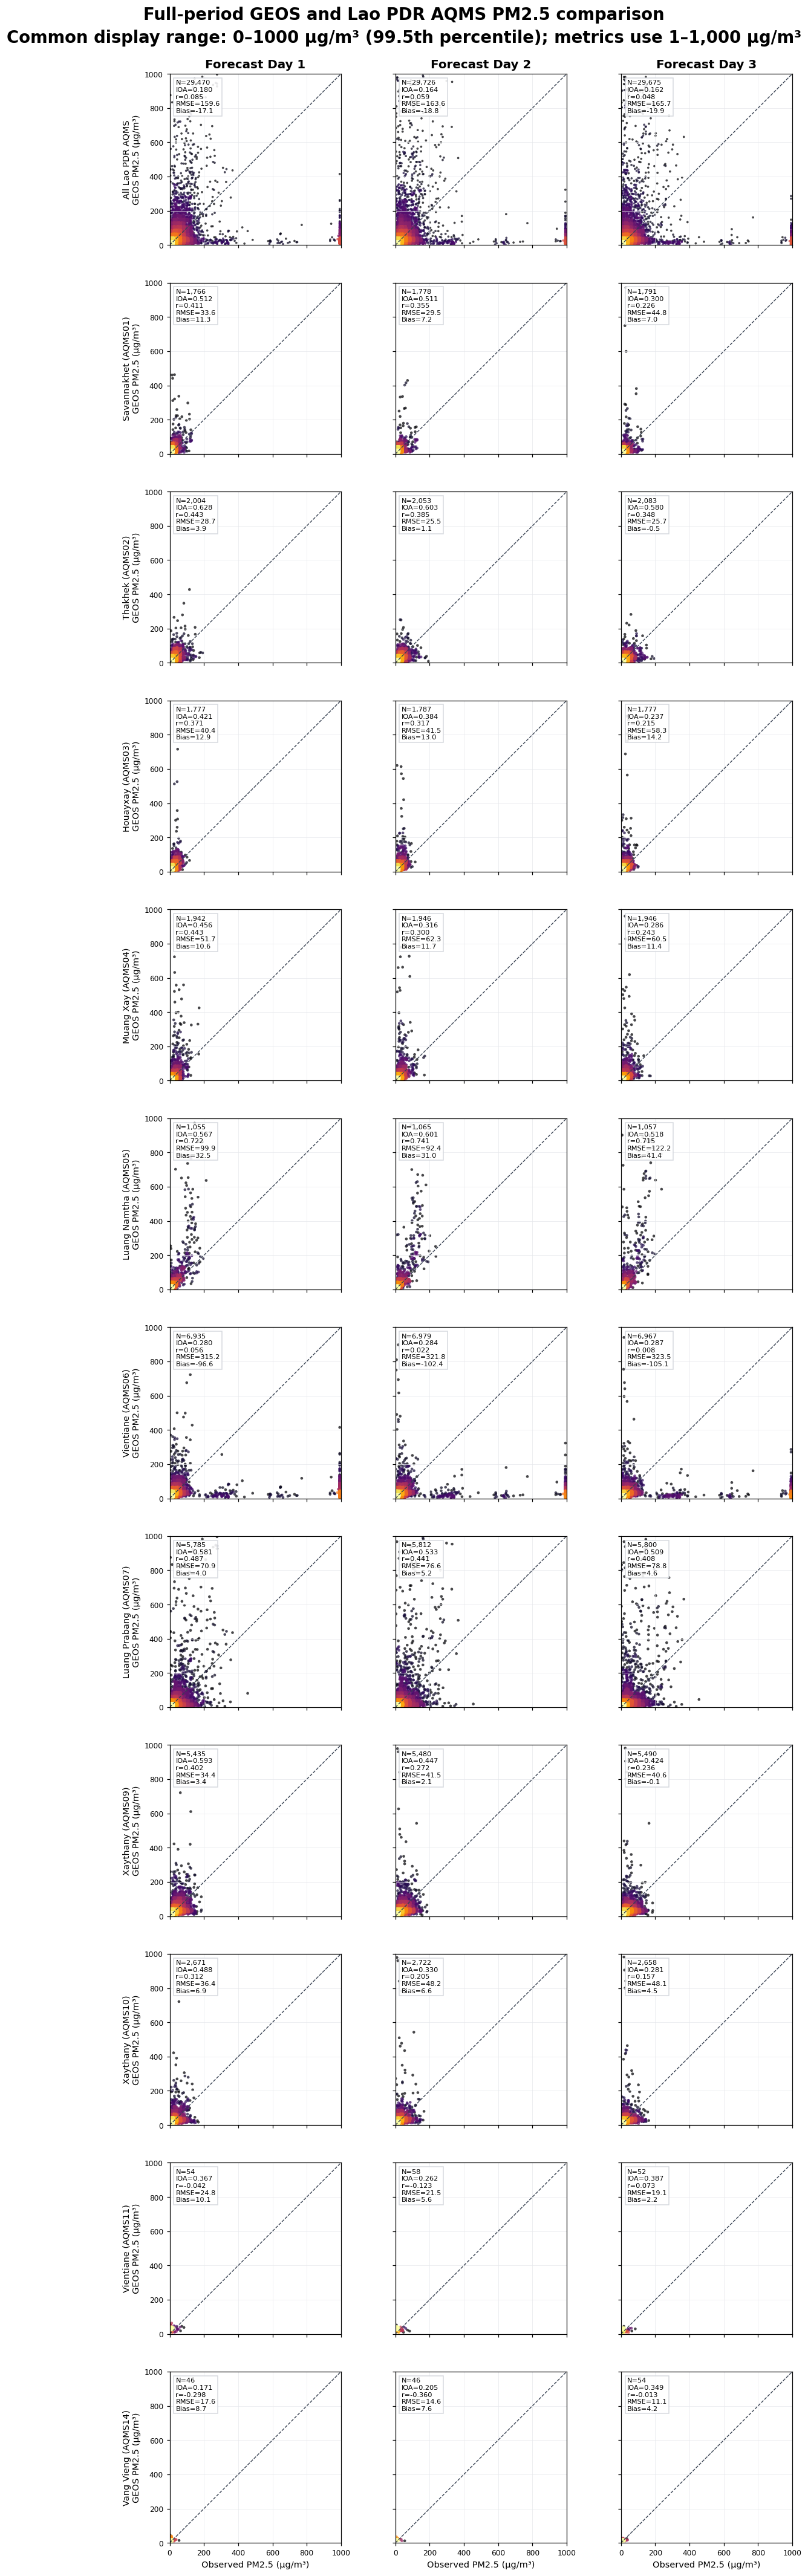

Common display maximum: 1000.0 µg/m³
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_full_period_aqms_scatter_matrix_metrics.csv
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_full_period_aqms_day1_day2_day3_scatter_matrix.png
Saved: {TRAINING_ROOT}/outputs/module2_station_collocation/module2_full_period_aqms_day1_day2_day3_scatter_matrix.pdf


,station_code,station_name,forecast_day,N,mean_bias,rmse,r,ioa
0,ALL,All Lao PDR AQMS,1,29470,-17.081413,159.557837,0.084778,0.180418
1,ALL,All Lao PDR AQMS,2,29726,-18.843806,163.555193,0.059417,0.164452
2,ALL,All Lao PDR AQMS,3,29675,-19.918683,165.661870,0.048174,0.161531
3,AQMS01,Savannakhet (AQMS01),1,1766,11.309601,33.603010,0.410740,0.511874
4,AQMS01,Savannakhet (AQMS01),2,1778,7.176597,29.511367,0.355024,0.511479
5,AQMS01,Savannakhet (AQMS01),3,1791,6.954327,44.840198,0.226326,0.299932
6,AQMS02,Thakhek (AQMS02),1,2004,3.945250,28.653064,0.442706,0.628095
7,AQMS02,Thakhek (AQMS02),2,2053,1.051585,25.527370,0.385004,0.603394
8,AQMS02,Thakhek (AQMS02),3,2083,-0.524867,25.660663,0.347712,0.579583
9,AQMS03,Houayxay (AQMS03),1,1777,12.945155,40.410246,0.371163,0.421427


In [23]:
# --- What this cell does ---
# Builds the combined and station-level Day 1–3 scatter matrix.
# Uses local point density for color while metrics use the complete valid sample.
# Omits stations with no collocated records and exports PNG, PDF, and metrics CSV files.
# --- End annotation ---

def aqms_scatter_metrics(frame):
    observed = frame["observed_pm25"].to_numpy(dtype=float)
    modeled = frame["GEOSPM25"].to_numpy(dtype=float)
    error = modeled - observed
    if len(frame) == 0:
        return {"N": 0, "mean_bias": np.nan, "rmse": np.nan, "r": np.nan, "ioa": np.nan}
    observed_mean = observed.mean()
    ioa_denominator = np.sum(
        (np.abs(modeled - observed_mean) + np.abs(observed - observed_mean)) ** 2
    )
    correlation = (
        np.corrcoef(observed, modeled)[0, 1]
        if len(frame) > 1 and observed.std() > 0 and modeled.std() > 0
        else np.nan
    )
    return {
        "N": len(frame),
        "mean_bias": error.mean(),
        "rmse": np.sqrt(np.mean(error ** 2)),
        "r": correlation,
        "ioa": 1.0 - np.sum(error ** 2) / ioa_denominator
        if ioa_denominator > 0
        else np.nan,
    }


all_values = np.concatenate([
    full_aqms_evaluation["observed_pm25"].to_numpy(dtype=float),
    full_aqms_evaluation["GEOSPM25"].to_numpy(dtype=float),
])
display_percentile = 99.5
axis_max = np.ceil(np.nanpercentile(all_values, display_percentile) / 50.0) * 50.0
axis_max = float(np.clip(axis_max, 100.0, 1000.0))

station_lookup = dict(
    aqms_station_metadata[["station_code", "station_name"]].itertuples(index=False, name=None)
)
available_aqms_codes = [
    station_code
    for station_code in aqms_codes
    if full_aqms_evaluation["station_code"].eq(station_code).any()
]
matrix_rows = [("ALL", "All Lao PDR AQMS")] + [
    (station_code, f"{station_lookup.get(station_code, station_code)} ({station_code})")
    for station_code in available_aqms_codes
]
forecast_days = [1, 2, 3]
matrix_metrics = []

fig, axes = plt.subplots(
    len(matrix_rows),
    len(forecast_days),
    figsize=(12.5, 3.25 * len(matrix_rows)),
    dpi=110,
    sharex=True,
    sharey=True,
)

for row_index, (station_code, row_label) in enumerate(matrix_rows):
    for column_index, forecast_day in enumerate(forecast_days):
        ax = axes[row_index, column_index]
        panel_data = full_aqms_evaluation.loc[
            full_aqms_evaluation["forecast_day"].eq(forecast_day)
        ]
        if station_code != "ALL":
            panel_data = panel_data.loc[panel_data["station_code"].eq(station_code)]

        metrics = aqms_scatter_metrics(panel_data)
        matrix_metrics.append({
            "station_code": station_code,
            "station_name": row_label,
            "forecast_day": forecast_day,
            **metrics,
        })

        if not panel_data.empty:
            observed = panel_data["observed_pm25"].to_numpy(dtype=float)
            modeled = panel_data["GEOSPM25"].to_numpy(dtype=float)
            # A 2-D histogram supplies each point's local density; the scatter itself still shows individual records.
            histogram, x_edges, y_edges = np.histogram2d(
                observed,
                modeled,
                bins=45,
                range=[[0, axis_max], [0, axis_max]],
            )
            x_index = np.clip(np.digitize(observed, x_edges) - 1, 0, histogram.shape[0] - 1)
            y_index = np.clip(np.digitize(modeled, y_edges) - 1, 0, histogram.shape[1] - 1)
            density = histogram[x_index, y_index]
            plot_order = np.argsort(density)
            ax.scatter(
                observed[plot_order],
                modeled[plot_order],
                c=np.log1p(density[plot_order]),
                cmap="inferno",
                s=6 if station_code == "ALL" else 9,
                alpha=0.72,
                edgecolors="none",
                rasterized=True,
            )
        else:
            ax.text(
                0.5,
                0.5,
                "No valid collocated records",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=9,
                color="#6b7280",
            )

        ax.plot([0, axis_max], [0, axis_max], color="#374151", linestyle="--", linewidth=0.9)
        ax.set_xlim(0, axis_max)
        ax.set_ylim(0, axis_max)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(color="#e5e7eb", linewidth=0.45)
        ax.tick_params(labelsize=8)

        metric_text = (
            f"N={int(metrics['N']):,}\n"
            f"IOA={metrics['ioa']:.3f}\n"
            f"r={metrics['r']:.3f}\n"
            f"RMSE={metrics['rmse']:.1f}\n"
            f"Bias={metrics['mean_bias']:.1f}"
            if metrics["N"] > 0
            else "N=0"
        )
        ax.text(
            0.035,
            0.965,
            metric_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=7.4,
            bbox={
                "boxstyle": "square,pad=0.28",
                "facecolor": "white",
                "edgecolor": "#d1d5db",
                "alpha": 0.88,
            },
        )

        if row_index == 0:
            ax.set_title(f"Forecast Day {forecast_day}", fontsize=13, fontweight="semibold")
        if column_index == 0:
            ax.set_ylabel(f"{row_label}\nGEOS PM2.5 (µg/m³)", fontsize=9.5)
        if row_index == len(matrix_rows) - 1:
            ax.set_xlabel("Observed PM2.5 (µg/m³)", fontsize=9.5)

matrix_metrics_table = pd.DataFrame(matrix_metrics)
matrix_metrics_output = OUTPUT_DIR / "module2_full_period_aqms_scatter_matrix_metrics.csv"
matrix_metrics_table.to_csv(matrix_metrics_output, index=False)

fig.suptitle(
    "Full-period GEOS and Lao PDR AQMS PM2.5 comparison\n"
    f"Common display range: 0–{axis_max:.0f} µg/m³ "
    f"({display_percentile:g}th percentile); metrics use 1–1,000 µg/m³",
    fontsize=18,
    fontweight="semibold",
    y=0.998,
    linespacing=1.45,
)
fig.subplots_adjust(left=0.20, right=0.985, top=0.972, bottom=0.02, hspace=0.22, wspace=0.12)

scatter_matrix_png = OUTPUT_DIR / "module2_full_period_aqms_day1_day2_day3_scatter_matrix.png"
scatter_matrix_pdf = OUTPUT_DIR / "module2_full_period_aqms_day1_day2_day3_scatter_matrix.pdf"
fig.savefig(scatter_matrix_png, dpi=160, bbox_inches="tight", facecolor="white")
fig.savefig(scatter_matrix_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Common display maximum:", axis_max, "µg/m³")
print("Saved:", matrix_metrics_output)
print("Saved:", scatter_matrix_png)
print("Saved:", scatter_matrix_pdf)
display(matrix_metrics_table)


## Section 7: Participant exercise — evaluate one AQMS station

**Question:** Is GEOS PM2.5 performance consistent across forecast Days 1–3 at one Lao PDR AQMS station?

**Time:** 45 minutes  
**Work mode:** pairs  
**Deliverables:** one data-audit table, one three-panel scatter figure, one metrics table, and three interpretation statements.

Use the compact full-period dataset created in Section 6. Apply the same rules used throughout the module: retain `n_obs = 3`, use the valid PM2.5 range of 1–1,000 µg/m³, keep initialization time distinct from valid time, and define error as `GEOS - observed`.


### Exercise setup

Run this cell, then select any station with available records. Avoid choosing the combined `ALL` category because this exercise focuses on station-level behavior.


In [24]:
# --- What this cell does ---
# Loads the compact full-period table used by the participant exercise.
# Lists valid station choices, record counts, date ranges, and forecast-day coverage.
# --- End annotation ---

EXERCISE_DATA_FILE = OUTPUT_DIR / "module2_full_period_aqms_geos_evaluation.csv"
exercise_data = pd.read_csv(
    EXERCISE_DATA_FILE,
    parse_dates=["initialization_time_utc", "datetime_utc"],
)

exercise_station_choices = (
    exercise_data.groupby(["station_code", "station_name"], as_index=False)
    .agg(
        N=("observed_pm25", "size"),
        first_valid_time_utc=("datetime_utc", "min"),
        last_valid_time_utc=("datetime_utc", "max"),
        forecast_days=("forecast_day", "nunique"),
    )
    .sort_values("station_code")
)

print("Choose one station_code from this table:")
display(exercise_station_choices)


Choose one station_code from this table:


,station_code,station_name,N,first_valid_time_utc,last_valid_time_utc,forecast_days
0,AQMS01,Savannakhet,5335,2021-12-23 04:30:00+00:00,2024-10-02 22:30:00+00:00,3
1,AQMS02,Thakhek,6140,2022-05-19 07:30:00+00:00,2023-05-11 22:30:00+00:00,3
2,AQMS03,Houayxay,5341,2021-12-03 13:30:00+00:00,2022-10-31 13:30:00+00:00,3
3,AQMS04,Muang Xay,5834,2021-11-27 07:30:00+00:00,2022-11-14 13:30:00+00:00,3
4,AQMS05,Luang Namtha,3177,2022-10-30 13:30:00+00:00,2024-07-29 13:30:00+00:00,3
5,AQMS06,Vientiane,20881,2020-01-21 19:30:00+00:00,2024-08-28 19:30:00+00:00,3
6,AQMS07,Luang Prabang,17397,2020-01-21 19:30:00+00:00,2023-02-01 01:30:00+00:00,3
7,AQMS09,Xaythany,16405,2020-01-21 16:30:00+00:00,2022-08-21 04:30:00+00:00,3
8,AQMS10,Xaythany,8051,2020-03-24 19:30:00+00:00,2021-08-18 13:30:00+00:00,3
9,AQMS11,Vientiane,164,2024-09-22 13:30:00+00:00,2024-10-02 22:30:00+00:00,3


### Exercise 1 — Audit your station sample (10 minutes)

1. Replace `AQMS02` with your selected station.
2. Count records for each forecast day.
3. Report the first and last valid UTC timestamps.
4. Confirm that observed and GEOS PM2.5 remain within 1–1,000 µg/m³.
5. Confirm that all three forecast days are represented.


In [ ]:
# --- What this cell does ---
# Participant task: select one station and construct a QA/QC audit table.
# The TODO comments identify the required operations without supplying the answer.
# --- End annotation ---

EXERCISE_STATION = "AQMS02"  # Change this station code.

station_exercise = exercise_data.loc[
    exercise_data["station_code"].eq(EXERCISE_STATION)
].copy()

# TODO: group by forecast_day and calculate N, first time, last time,
# observed minimum/maximum, and GEOS minimum/maximum.
station_audit = None

# TODO: add assertions for n_obs and the valid PM2.5 range.

station_audit


### Exercise 2 — Calculate evaluation metrics (10 minutes)

For each forecast day, calculate:

- `N`
- Mean bias: mean of `GEOSPM25 - observed_pm25`
- RMSE
- Pearson correlation (`r`)
- Index of Agreement (IOA)

Use the original Willmott IOA with error power `j = 2`. Decide which forecast day has the lowest RMSE and which has the highest IOA.


In [ ]:
# --- What this cell does ---
# Participant task: calculate evaluation metrics separately for each forecast day.
# Observed and modeled arrays are provided; participants complete the formulas.
# --- End annotation ---

exercise_metric_rows = []

for forecast_day, day_data in station_exercise.groupby("forecast_day", sort=True):
    observed = day_data["observed_pm25"].to_numpy(dtype=float)
    modeled = day_data["GEOSPM25"].to_numpy(dtype=float)
    error = modeled - observed

    # TODO: calculate N, mean bias, RMSE, r, and IOA.
    # TODO: append one dictionary per forecast day to exercise_metric_rows.

exercise_metrics = pd.DataFrame(exercise_metric_rows)
exercise_metrics


### Exercise 3 — Build the Day 1–3 scatter figure (15 minutes)

Create one row with three panels. Use the same x- and y-axis range in every panel, draw a dashed 1:1 line, enforce a square plotting area, and place the metrics inside each panel. Label initialization and valid times correctly in your description of the analysis.

**Extension:** color points by observed concentration or local point density.


In [ ]:
# --- What this cell does ---
# Participant task: create three square scatter panels with common axes.
# Participants add points, the 1:1 line, labels, and metric annotations.
# --- End annotation ---

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), dpi=140)

for ax, forecast_day in zip(axes, [1, 2, 3]):
    day_data = station_exercise.loc[
        station_exercise["forecast_day"].eq(forecast_day)
    ]

    # TODO: draw observed_pm25 versus GEOSPM25.
    # TODO: add the 1:1 line, common limits, square aspect, and metric text.
    ax.set_title(f"Forecast Day {forecast_day}")

# TODO: add shared meaning through clear axis labels and a station title.
fig.tight_layout()
plt.show()


### Exercise 4 — Interpret and communicate (10 minutes)

Write three concise statements supported by your table and figure:

1. **Agreement:** Which forecast day performs best, and which metric supports that conclusion?
2. **Bias:** Does GEOS tend to overestimate or underestimate PM2.5 at this station? Does the sign change by forecast day?
3. **Limitation:** Identify one reason the station-level result should not automatically be generalized to all Lao PDR AQMS stations.

**Optional challenge:** repeat the metrics using only observations at or above 50 µg/m³. Explain how the sample size and model behavior change.


### Completion checklist

- [ ] Selected one station with valid records on forecast Days 1–3
- [ ] Verified `n_obs = 3` and the 1–1,000 µg/m³ valid range
- [ ] Preserved initialization time and valid time as different fields
- [ ] Produced a station audit table
- [ ] Calculated `N`, mean bias, RMSE, `r`, and IOA
- [ ] Produced three square scatter panels with common axes and a 1:1 line
- [ ] Wrote three evidence-based interpretation statements


## Module 2 checkpoint

Participants should now be able to explain and reproduce:

1. how Thai PCD and Lao PDR AQMS source files differ;
2. how missing, nonnumeric, and out-of-range PM2.5 values are distinguished;
3. how daily and monthly station analyses are created after QA/QC;
4. how Haversine nearest-center collocation links stations to the GEOS grid;
5. how saved grid indices support reproducible multi-file extraction;
6. how local observations are converted to UTC;
7. how `[00:00,03:00)` and subsequent UTC intervals are averaged and timestamped at their midpoints;
8. why exactly three distinct valid hourly observations are required (`n_obs = 3`);
9. how ground and GEOS records are matched by station and valid UTC time while retaining forecast-cycle provenance; and
10. how bias, RMSE, correlation, and IOA describe model–observation agreement.
